# HAM10000 RG-MF Reviewer-3/4 Additional Experiment Notebook - GOOGLE COLAB

Notebook ini dibuat dari kode eksperimen terakhir dan ditambahkan eksperimen yang diminta reviewer terbaru IEEE Access untuk paper:

**Reliability-Gated Multimodal Fusion Algorithm for Teledermatology Under Missing and Corrupted Metadata**

Tambahan utama dibanding notebook sebelumnya:

1. **Rule-based r\* gate baseline**: metadata gating langsung memakai `r_target = mean(a ⊙ p)`, tanpa reliability MLP.
2. **Metadata-only baseline**: mengukur seberapa kuat metadata tanpa citra dermoskopi.
3. **Metadata contribution / image-dominated analysis**: membandingkan RG-MF full gate, rule-r\* gate, no-gate, static-mean, dan zero-metadata gate.
4. **Modality norm probe**: mengukur rasio kontribusi metadata setelah gating terhadap representasi visual.
5. **Targeted non-MCAR metadata stress test**: stress metadata berdasarkan kondisi tertentu, bukan hanya random MCAR.
6. **Exact corruption and plausibility rule table**: tabel siap masuk paper/response.

Gunakan runtime GPU Google Colab. Jalankan semua cell berurutan. Untuk hasil final paper, gunakan `RUN_PROFILE = "paper_fast"` atau `"paper_strong"`.


In [1]:
# ============================================================
# 0. INSTALL DEPENDENCIES - COLAB
# ============================================================
# Jalankan cell ini di Google Colab. Jika semua package sudah tersedia, prosesnya cepat.
!pip -q install timm scikit-learn pandas matplotlib tqdm


In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================
import os
import gc
import time
import copy
import math
import json
import random
import hashlib
import shutil
import zipfile
import subprocess
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import timm

# Speed setting for Ampere/T4/A100 when available.
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
# Safe display fallback: works in Jupyter/Colab and also if executed as a plain Python script.
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# ============================================================
# 2. CONFIGURATION - GOOGLE COLAB FAST
# ============================================================

# -------------------------
# GOOGLE DRIVE MOUNT
# -------------------------
IN_COLAB = False
try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore
    IN_COLAB = True
    drive.mount('/content/drive')
except Exception as e:
    print("Tidak berjalan di Google Colab atau Drive tidak dimount otomatis:", repr(e))

# -------------------------
# DATASET PATH CONFIG - COLAB
# -------------------------
# Struktur yang disarankan:
# /content/drive/MyDrive/ham10000/HAM10000_metadata.csv
# /content/drive/MyDrive/ham10000/HAM10000_images/*.jpg
#
# Alternatif:
# /content/drive/MyDrive/ham10000.zip
# /content/drive/MyDrive/HAM10000.zip
#
# Notebook akan memakai local cache /content/ham10000_fast agar training lebih cepat.

DRIVE_DATA_ROOT = Path("/content/drive/MyDrive/ham10000")
LOCAL_CACHE_ROOT = Path("/content/ham10000_fast")
UNZIPPED_ROOT = Path("/content/ham10000_drive_unzipped")
USE_LOCAL_DATA_CACHE = True
AUTO_UNZIP_FROM_DRIVE = True

ZIP_CANDIDATES = [
    Path("/content/drive/MyDrive/ham10000.zip"),
    Path("/content/drive/MyDrive/HAM10000.zip"),
    Path("/content/drive/MyDrive/RISETKOLABORASI/ham10000.zip"),
]

def count_image_files(root: Path):
    if not Path(root).exists():
        return 0
    root = Path(root)
    exts = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    total = 0
    for ext in exts:
        total += len(list(root.rglob(ext)))
    return total

def has_ham10000_metadata(root: Path):
    return (Path(root) / "HAM10000_metadata.csv").exists()

def locate_extracted_dataset(root: Path):
    """Find folder containing HAM10000_metadata.csv after unzip."""
    root = Path(root)
    if has_ham10000_metadata(root):
        return root
    hits = list(root.rglob("HAM10000_metadata.csv"))
    if hits:
        return hits[0].parent
    return root

# Optional unzip from Drive if folder is not present.
if AUTO_UNZIP_FROM_DRIVE and not has_ham10000_metadata(DRIVE_DATA_ROOT):
    zip_path = None
    for z in ZIP_CANDIDATES:
        if z.exists():
            zip_path = z
            break
    if zip_path is not None:
        print(f"[INFO] Folder dataset belum ditemukan. Unzip dari: {zip_path}")
        UNZIPPED_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(UNZIPPED_ROOT)
        DRIVE_DATA_ROOT = locate_extracted_dataset(UNZIPPED_ROOT)
        print("[INFO] Dataset hasil unzip:", DRIVE_DATA_ROOT)
    else:
        print("[INFO] ZIP dataset tidak ditemukan di kandidat ZIP_CANDIDATES.")

SOURCE_DATA_ROOT = DRIVE_DATA_ROOT

# Copy dataset from Drive to local Colab runtime for faster image loading.
if USE_LOCAL_DATA_CACHE:
    need_copy = (not has_ham10000_metadata(LOCAL_CACHE_ROOT)) or (count_image_files(LOCAL_CACHE_ROOT) == 0)
    if need_copy:
        if not has_ham10000_metadata(SOURCE_DATA_ROOT):
            raise FileNotFoundError(
                "HAM10000_metadata.csv tidak ditemukan. Upload dataset ke:\n"
                "  /content/drive/MyDrive/ham10000/HAM10000_metadata.csv\n"
                "atau upload ZIP ke:\n"
                "  /content/drive/MyDrive/ham10000.zip\n"
                f"SOURCE_DATA_ROOT saat ini: {SOURCE_DATA_ROOT}"
            )
        print(f"[INFO] Menyalin dataset ke local cache Colab untuk mempercepat training:\n  {SOURCE_DATA_ROOT}\n  -> {LOCAL_CACHE_ROOT}")
        if LOCAL_CACHE_ROOT.exists():
            shutil.rmtree(LOCAL_CACHE_ROOT)
        shutil.copytree(SOURCE_DATA_ROOT, LOCAL_CACHE_ROOT)
    else:
        print("[OK] Local cache dataset sudah tersedia:", LOCAL_CACHE_ROOT)
    DATA_ROOT = LOCAL_CACHE_ROOT
else:
    DATA_ROOT = SOURCE_DATA_ROOT

METADATA_PATH = DATA_ROOT / "HAM10000_metadata.csv"
# Jika folder HAM10000_images tidak ada, gunakan DATA_ROOT agar rglob menemukan HAM10000_images_part_1/part_2.
IMAGE_DIR = DATA_ROOT / "HAM10000_images"
if not IMAGE_DIR.exists():
    IMAGE_DIR = DATA_ROOT

# Output lokal lebih cepat. Di akhir notebook, hasil akan dizip dan disalin ke Google Drive.
SAVE_DIR = Path("/content/ham10000_rg_mf_reviewer3_4_results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/ham10000_rg_mf_reviewer3_4_results")

print("DATA_ROOT        :", DATA_ROOT)
print("METADATA_PATH    :", METADATA_PATH, "| exists:", METADATA_PATH.exists())
print("IMAGE_DIR        :", IMAGE_DIR, "| images:", count_image_files(IMAGE_DIR))
print("SAVE_DIR local   :", SAVE_DIR)
print("DRIVE_RESULTS_DIR:", DRIVE_RESULTS_DIR)

# -------------------------
# RUN PROFILE
# -------------------------
# Pilihan:
# - "debug"        : cek pipeline cepat, bukan untuk paper.
# - "paper_fast"   : minimal kuat untuk reviewer 2, 3 seeds.
# - "paper_strong" : lebih kuat, 5 seeds, lebih lama.
RUN_PROFILE = "paper_fast"

if RUN_PROFILE == "debug":
    SEEDS = [42]
    EPOCHS = 1
    PATIENCE = 1
    DEBUG_FAST_RUN = True
    DEBUG_N_TRAIN = 400
    DEBUG_N_VAL = 120
    DEBUG_N_TEST = 160
    N_BOOTSTRAP = 100
elif RUN_PROFILE == "paper_fast":
    SEEDS = [42, 123, 2025]
    EPOCHS = 6
    PATIENCE = 2
    DEBUG_FAST_RUN = False
    DEBUG_N_TRAIN = 800
    DEBUG_N_VAL = 200
    DEBUG_N_TEST = 300
    N_BOOTSTRAP = 500
elif RUN_PROFILE == "paper_strong":
    SEEDS = [42, 123, 2025, 3407, 777]
    EPOCHS = 8
    PATIENCE = 3
    DEBUG_FAST_RUN = False
    DEBUG_N_TRAIN = 800
    DEBUG_N_VAL = 200
    DEBUG_N_TEST = 300
    N_BOOTSTRAP = 1000
else:
    raise ValueError("RUN_PROFILE harus: debug, paper_fast, atau paper_strong")

# -------------------------
# CHECKPOINT / OUTPUT CONFIG
# -------------------------
SAVE_CHECKPOINTS = True
RESUME_IF_CHECKPOINT_EXISTS = True
SAVE_PREDICTIONS = True
RUN_MODEL_SANITY_CHECK = False

# -------------------------
# MODEL CONFIG
# -------------------------
MODEL_NAME = "vit_base_patch16_224"
PRETRAINED = True
FREEZE_BACKBONE = False
IMG_SIZE = 224

# T4 biasanya aman BATCH_SIZE 16. Jika A100/L4 bisa coba 24/32.
BATCH_SIZE = 16
NUM_WORKERS = 2
LR = 2e-5
WEIGHT_DECAY = 1e-4
AMP = True
BOOTSTRAP_RANDOM_STATE = 2026
LATENCY_WARMUP_BATCHES = 2
LATENCY_MEASURE_BATCHES = 5

# -------------------------
# STRESS TEST CONFIG
# -------------------------
STRESS_RATES = [0.0, 0.25, 0.50, 0.75]
STRESS_TYPES = ["missing", "corruption"]

# -------------------------
# MODEL LIST
# -------------------------
MODELS_TO_RUN = [
    "ViT Image-Only",
    "Prior Fusion",
    "RG-MF",
    "RG-MF Rule-r*",
    "Metadata-Only",
]

# -------------------------
# REVIEWER 3/4 ADDITIONAL ANALYSIS CONFIG
# -------------------------
# Rule-based r* gate uses r_target = mean(a * p) directly as the metadata gate.
# Zero-metadata gate sets r=0 at inference to quantify whether the classifier is image-dominated.
RUN_METADATA_CONTRIBUTION_ANALYSIS = True
RUN_MODALITY_NORM_PROBE = True
RUN_NON_MCAR_STRESS = True

# -------------------------
# METADATA ROBUSTNESS TRAINING
# -------------------------
TRAIN_METADATA_AUGMENTATION = True
TRAIN_STRESS_MODE = "mixed"
TRAIN_STRESS_RATE = 0.35
RELIABILITY_LOSS_WEIGHT = 0.20
RELIABILITY_LOSS_TYPE = "mse"

# -------------------------
# CLASS IMBALANCE HANDLING
# -------------------------
USE_WEIGHTED_SAMPLER = True
LOSS_MODE = "weighted_ce"

# -------------------------
# DEVICE
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("RUN_PROFILE:", RUN_PROFILE)
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU tidak aktif. Di Colab pilih Runtime > Change runtime type > GPU.")


Mounted at /content/drive
[INFO] Menyalin dataset ke local cache Colab untuk mempercepat training:
  /content/drive/MyDrive/ham10000
  -> /content/ham10000_fast
DATA_ROOT        : /content/ham10000_fast
METADATA_PATH    : /content/ham10000_fast/HAM10000_metadata.csv | exists: True
IMAGE_DIR        : /content/ham10000_fast/HAM10000_images | images: 10015
SAVE_DIR local   : /content/ham10000_rg_mf_reviewer3_4_results
DRIVE_RESULTS_DIR: /content/drive/MyDrive/ham10000_rg_mf_reviewer3_4_results
RUN_PROFILE: paper_fast
DEVICE: cuda
GPU: Tesla T4


In [6]:
# ============================================================
# 2.A CONFIG PRE-FLIGHT CHECK
# ============================================================

_REQUIRED_CONFIG_NAMES = [
    "SEEDS",
    "STRESS_RATES",
    "STRESS_TYPES",
    "N_BOOTSTRAP",
    "BOOTSTRAP_RANDOM_STATE",
    "LATENCY_WARMUP_BATCHES",
    "LATENCY_MEASURE_BATCHES",
    "MODELS_TO_RUN",
    "TRAIN_METADATA_AUGMENTATION",
    "TRAIN_STRESS_MODE",
    "TRAIN_STRESS_RATE",
    "RELIABILITY_LOSS_WEIGHT",
    "RELIABILITY_LOSS_TYPE",
    "USE_WEIGHTED_SAMPLER",
    "LOSS_MODE",
    "SAVE_CHECKPOINTS",
    "RESUME_IF_CHECKPOINT_EXISTS",
    "SAVE_PREDICTIONS",
    "RUN_MODEL_SANITY_CHECK",
    "DEVICE",
]

_missing_config = [name for name in _REQUIRED_CONFIG_NAMES if name not in globals()]

if _missing_config:
    raise NameError(f"Missing configuration variables: {_missing_config}")


# ============================================================
# VALID MODEL NAMES
# ============================================================
# Model utama revisi sebelumnya:
# - ViT Image-Only
# - Prior Fusion
# - RG-MF
#
# Model tambahan untuk menjawab Reviewer 3 dan Reviewer 4:
# - RG-MF Rule-r*  : rule-based gate using r* directly
# - Metadata-Only : metadata-only baseline

_valid_model_names = {
    "ViT Image-Only",
    "ViT Baseline",
    "Image-Only ViT",
    "Prior Fusion",
    "RG-MF",
    "RG-MF Rule-r*",
    "RG-MF Rule-rstar",
    "RG-MF Rule-r",
    "Rule-r*",
    "Rule-rstar",
    "Metadata-Only",
    "Metadata Only",
}

_bad_models = [m for m in MODELS_TO_RUN if m not in _valid_model_names]

if _bad_models:
    raise ValueError(
        f"Unsupported MODELS_TO_RUN names: {_bad_models}\n"
        f"Supported names are: {sorted(_valid_model_names)}"
    )

print("[OK] Config pre-flight check passed.")
print("Models to run:", MODELS_TO_RUN)
print("Seeds:", SEEDS)
print("Device:", DEVICE)

[OK] Config pre-flight check passed.
Models to run: ['ViT Image-Only', 'Prior Fusion', 'RG-MF', 'RG-MF Rule-r*', 'Metadata-Only']
Seeds: [42, 123, 2025]
Device: cuda


In [8]:
# ============================================================
# 3. REPRODUCIBILITY HELPERS
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Deterministic settings can reduce speed; use for reproducibility.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def stable_float01(*items):
    """
    Deterministic pseudo-random float in [0,1) from arbitrary items.
    Useful for nested stress testing: higher rates include lower-rate perturbations.
    """
    s = "|".join(map(str, items))
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return int(h[:8], 16) / 0xFFFFFFFF

def stable_choice(choices, *items):
    u = stable_float01(*items)
    idx = int(u * len(choices)) % len(choices)
    return choices[idx]

def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

seed_everything(42)

## 4. Load metadata, validasi kolom, dan indexing gambar

In [9]:
# ============================================================
# 4. LOAD METADATA AND IMAGE INDEX
# ============================================================

def check_path_or_raise(name, path):
    path = Path(path)
    if not path.exists():
        print(f"[ERROR] {name} tidak ditemukan: {path}")
        print("Cek kembali konfigurasi path pada Cell 2.")
        print("Tips Colab: pastikan dataset ada di /content/drive/MyDrive/ham10000 atau ZIP di /content/drive/MyDrive/ham10000.zip.")
        raise FileNotFoundError(f"{name} tidak ditemukan: {path}")
    print(f"[OK] {name}: {path}")
    return path

DATA_ROOT = check_path_or_raise("DATA_ROOT", DATA_ROOT)
METADATA_PATH = check_path_or_raise("METADATA_PATH", METADATA_PATH)
IMAGE_DIR = check_path_or_raise("IMAGE_DIR", IMAGE_DIR)

df = pd.read_csv(METADATA_PATH)
print("Raw metadata shape:", df.shape)
print("Columns:", df.columns.tolist())

required_cols = ["image_id", "dx", "age", "sex", "localization"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}")

group_col = "patient_id" if "patient_id" in df.columns else ("lesion_id" if "lesion_id" in df.columns else None)
if group_col is None:
    raise ValueError("Metadata harus punya 'patient_id' atau 'lesion_id' untuk grouped split anti-leakage.")

print("Grouping column:", group_col)
if group_col != "patient_id":
    print("Catatan: patient_id tidak tersedia. Notebook memakai lesion_id sebagai proxy grouping.")

def build_image_index(image_dir: Path):
    image_files = list(image_dir.rglob("*.jpg")) + list(image_dir.rglob("*.jpeg")) + list(image_dir.rglob("*.png"))
    index = {}
    for p in image_files:
        index[p.stem] = str(p)
    return index

image_index = build_image_index(IMAGE_DIR)
print("Jumlah gambar ditemukan:", len(image_index))

df["image_id"] = df["image_id"].astype(str)
df["image_path"] = df["image_id"].map(image_index)
found = int(df["image_path"].notna().sum())
print(f"Image paths found: {found}/{len(df)}")

if found == 0:
    print("Contoh image_id dari metadata:", df["image_id"].head(10).tolist())
    print("Contoh nama file gambar tanpa ekstensi:", list(image_index.keys())[:10])
    raise FileNotFoundError("Tidak ada image_path yang cocok dengan image_id metadata. Pastikan nama file gambar sama dengan kolom image_id.")

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

# Basic metadata normalization.
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["sex"] = df["sex"].astype(str).str.lower().replace({"nan": "unknown"})
df["localization"] = df["localization"].astype(str).str.lower().replace({"nan": "unknown"})
df["dx"] = df["dx"].astype(str)

# Optional debug subsampling for quick smoke test.
if DEBUG_FAST_RUN:
    print("DEBUG_FAST_RUN aktif.")
    df = df.sample(n=min(len(df), DEBUG_N_TRAIN + DEBUG_N_VAL + DEBUG_N_TEST), random_state=42).reset_index(drop=True)

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

print("Final usable df shape:", df.shape)
print("Classes:", class_names)
display(df.head())


[OK] DATA_ROOT: /content/ham10000_fast
[OK] METADATA_PATH: /content/ham10000_fast/HAM10000_metadata.csv
[OK] IMAGE_DIR: /content/ham10000_fast/HAM10000_images
Raw metadata shape: (10015, 7)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
Grouping column: lesion_id
Catatan: patient_id tidak tersedia. Notebook memakai lesion_id sebagai proxy grouping.
Jumlah gambar ditemukan: 10015
Image paths found: 10015/10015
Final usable df shape: (10015, 9)
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham10000_fast/HAM10000_images/ISIC_00...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham10000_fast/HAM10000_images/ISIC_00...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham10000_fast/HAM10000_images/ISIC_00...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham10000_fast/HAM10000_images/ISIC_00...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham10000_fast/HAM10000_images/ISIC_00...,2


## 5. Grouped split per seed dan metadata vocabulary per training split

Reviewer 2 mengkritik single patient-level split. Cell berikut membuat split baru untuk setiap seed dengan grouping anti-leakage.

In [10]:
# ============================================================
# 5. SPLIT AND METADATA PREPARATION PER SEED
# ============================================================
def normalize_age_value(age, age_min, age_max):
    denom = max(float(age_max) - float(age_min), 1e-8)
    return (float(age) - float(age_min)) / denom

def build_split_for_seed(df_all, seed, train_size=0.70, val_size=0.15, test_size=0.15):
    if abs(train_size + val_size + test_size - 1.0) > 1e-6:
        raise ValueError("train_size + val_size + test_size must equal 1.")

    groups = df_all[group_col].astype(str)
    gss_1 = GroupShuffleSplit(n_splits=1, test_size=(1.0 - train_size), random_state=seed)
    train_idx, temp_idx = next(gss_1.split(df_all, groups=groups))

    df_train = df_all.iloc[train_idx].reset_index(drop=True)
    df_temp = df_all.iloc[temp_idx].reset_index(drop=True)

    relative_test_size = test_size / (val_size + test_size)
    gss_2 = GroupShuffleSplit(n_splits=1, test_size=relative_test_size, random_state=seed + 1000)
    val_idx, test_idx = next(gss_2.split(df_temp, groups=df_temp[group_col].astype(str)))

    df_val = df_temp.iloc[val_idx].reset_index(drop=True)
    df_test = df_temp.iloc[test_idx].reset_index(drop=True)

    # Optional quick debug mode. These variables are defined in Cell 2.
    # Use DEBUG_FAST_RUN=True only for checking the pipeline; use False for final paper results.
    if DEBUG_FAST_RUN:
        df_train = df_train.sample(min(DEBUG_N_TRAIN, len(df_train)), random_state=seed).reset_index(drop=True)
        df_val = df_val.sample(min(DEBUG_N_VAL, len(df_val)), random_state=seed).reset_index(drop=True)
        df_test = df_test.sample(min(DEBUG_N_TEST, len(df_test)), random_state=seed).reset_index(drop=True)

    train_groups = set(df_train[group_col].astype(str))
    val_groups = set(df_val[group_col].astype(str))
    test_groups = set(df_test[group_col].astype(str))

    assert train_groups.isdisjoint(val_groups)
    assert train_groups.isdisjoint(test_groups)
    assert val_groups.isdisjoint(test_groups)

    # Age stats from train only.
    train_age_median = float(df_train["age"].median())
    train_age_min = float(df_train["age"].min())
    train_age_max = float(df_train["age"].max())

    # Vocab from train only + unknown.
    sex_vocab = sorted(set(df_train["sex"].astype(str).str.lower().tolist()) | {"unknown"})
    loc_vocab = sorted(set(df_train["localization"].astype(str).str.lower().tolist()) | {"unknown"})

    sex_to_idx = {v: i for i, v in enumerate(sex_vocab)}
    loc_to_idx = {v: i for i, v in enumerate(loc_vocab)}

    split_info = {
        "seed": seed,
        "df_train": df_train,
        "df_val": df_val,
        "df_test": df_test,
        "train_age_median": train_age_median,
        "train_age_min": train_age_min,
        "train_age_max": train_age_max,
        "sex_to_idx": sex_to_idx,
        "loc_to_idx": loc_to_idx,
    }

    print(f"[Seed {seed}] Train={df_train.shape}, Val={df_val.shape}, Test={df_test.shape}")
    print(f"[Seed {seed}] Groups train/val/test = {len(train_groups)}/{len(val_groups)}/{len(test_groups)}")
    return split_info

# Sanity check one split.
_ = build_split_for_seed(df, SEEDS[0])

[Seed 42] Train=(7000, 9), Val=(1466, 9), Test=(1549, 9)
[Seed 42] Groups train/val/test = 5228/1121/1121


## 6. Transform dan Dataset dengan deterministic nested stress-test

Perubahan penting dibanding kode lama:
- Missingness/corruption tidak lagi memakai `random.random()` saat `__getitem__`.
- Stress mask dibuat deterministik per `(seed, sample_index, field)`.
- Rate 0.75 otomatis mencakup subset 0.50 dan 0.25 sehingga evaluasi lebih stabil dan reprodusibel.
- Dataset mengembalikan `r_target` agar reliability head tidak collapse menjadi konstanta.

In [11]:
# ============================================================
# 6. TRANSFORMS AND DATASET
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class HAM10000ReliabilityDataset(Dataset):
    """
    HAM10000 dataset with deterministic metadata stress testing and reliability target.

    stress_mode:
      - "clean": no synthetic perturbation.
      - "missing": deterministic nested masking at stress_rate.
      - "corruption": deterministic nested corruption at stress_rate.
      - "mixed": deterministic mix of missing and corruption at stress_rate. Intended for train augmentation.

    r_target:
      mean(availability * plausibility) across age, sex, and localization.
      It is not a clinical ground-truth annotation, but a transparent metadata-quality proxy
      used to anchor the reliability gate and directly answer the reviewer's collapse concern.
    """
    def __init__(
        self,
        dataframe,
        transform,
        sex_to_idx,
        loc_to_idx,
        age_min,
        age_max,
        age_median,
        stress_mode="clean",
        stress_rate=0.0,
        stress_seed=42,
        unknown_is_low_conf=True,
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.sex_to_idx = sex_to_idx
        self.loc_to_idx = loc_to_idx
        self.age_min = float(age_min)
        self.age_max = float(age_max)
        self.age_median = float(age_median)
        self.stress_mode = stress_mode
        self.stress_rate = float(stress_rate)
        self.stress_seed = int(stress_seed)
        self.unknown_is_low_conf = bool(unknown_is_low_conf)

        allowed = {"clean", "missing", "corruption", "mixed"}
        if self.stress_mode not in allowed:
            raise ValueError(f"Unknown stress_mode={stress_mode}. Must be one of {allowed}")

    def __len__(self):
        return len(self.df)

    def safe_sex_idx(self, val):
        val = str(val).lower()
        return self.sex_to_idx.get(val, self.sex_to_idx["unknown"])

    def safe_loc_idx(self, val):
        val = str(val).lower()
        return self.loc_to_idx.get(val, self.loc_to_idx["unknown"])

    def _field_selected(self, idx, field_name):
        # Nested: if selected at 0.25, also selected at 0.50 and 0.75.
        u = stable_float01("select", self.stress_seed, self.stress_mode, idx, field_name)
        return u < self.stress_rate

    def _mixed_action(self, idx, field_name):
        u = stable_float01("mixed_action", self.stress_seed, idx, field_name)
        return "missing" if u < 0.5 else "corruption"

    def _corrupt_age(self, age, idx):
        choices = [-10.0, 135.0, float(age) - 50.0, float(age) + 50.0]
        return stable_choice(choices, "age_corrupt", self.stress_seed, idx)

    def _corrupt_sex(self, sex, idx):
        choices = ["male", "female", "unknown", "invalid_sex"]
        chosen = stable_choice(choices, "sex_corrupt", self.stress_seed, idx)
        if chosen == sex and sex in ["male", "female"]:
            chosen = "female" if sex == "male" else "male"
        return chosen

    def _corrupt_loc(self, loc, idx):
        choices = list(self.loc_to_idx.keys()) + ["invalid_site"]
        chosen = stable_choice(choices, "loc_corrupt", self.stress_seed, idx)
        if chosen == loc and len(choices) > 1:
            chosen = "invalid_site"
        return chosen

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        # Original metadata.
        original_age_missing = pd.isna(row["age"])
        age = self.age_median if original_age_missing else float(row["age"])
        sex = str(row["sex"]).lower() if str(row["sex"]).lower() != "nan" else "unknown"
        loc = str(row["localization"]).lower() if str(row["localization"]).lower() != "nan" else "unknown"

        # Availability cues from original data.
        age_avail = 0.0 if original_age_missing else 1.0
        sex_avail = 0.0 if sex == "unknown" else 1.0
        loc_avail = 0.0 if loc == "unknown" else 1.0

        # Apply deterministic synthetic perturbations.
        if self.stress_mode != "clean" and self.stress_rate > 0:
            for field_name in ["age", "sex", "loc"]:
                if not self._field_selected(idx, field_name):
                    continue

                action = self.stress_mode
                if self.stress_mode == "mixed":
                    action = self._mixed_action(idx, field_name)

                if field_name == "age":
                    if action == "missing":
                        age = self.age_median
                        age_avail = 0.0
                    elif action == "corruption":
                        age = self._corrupt_age(age, idx)
                        age_avail = 1.0

                elif field_name == "sex":
                    if action == "missing":
                        sex = "unknown"
                        sex_avail = 0.0
                    elif action == "corruption":
                        sex = self._corrupt_sex(sex, idx)
                        sex_avail = 1.0

                elif field_name == "loc":
                    if action == "missing":
                        loc = "unknown"
                        loc_avail = 0.0
                    elif action == "corruption":
                        loc = self._corrupt_loc(loc, idx)
                        loc_avail = 1.0

        # Plausibility cues.
        age_plaus = 1.0
        sex_plaus = 1.0
        loc_plaus = 1.0

        if float(age) < 0 or float(age) > 120:
            age_plaus = 0.0

        if sex not in self.sex_to_idx:
            sex_plaus = 0.0
            sex = "unknown"

        if loc not in self.loc_to_idx:
            loc_plaus = 0.0
            loc = "unknown"

        if self.unknown_is_low_conf:
            if age_avail == 0.0:
                age_plaus = min(age_plaus, 0.5)
            if sex == "unknown":
                sex_plaus = min(sex_plaus, 0.5)
            if loc == "unknown":
                loc_plaus = min(loc_plaus, 0.5)

        age_clip = np.clip(float(age), self.age_min, self.age_max)
        age_norm = normalize_age_value(age_clip, self.age_min, self.age_max)

        availability = np.array([age_avail, sex_avail, loc_avail], dtype=np.float32)
        plausibility = np.array([age_plaus, sex_plaus, loc_plaus], dtype=np.float32)
        missing_rate_obs = np.array([(1.0 - availability).mean()], dtype=np.float32)
        implausibility_rate_obs = np.array([(1.0 - plausibility).mean()], dtype=np.float32)

        # Metadata-quality proxy used as reliability target.
        r_target = np.array([(availability * plausibility).mean()], dtype=np.float32)

        meta_dict = {
            "age": torch.tensor([age_norm], dtype=torch.float32),
            "sex_idx": torch.tensor(self.safe_sex_idx(sex), dtype=torch.long),
            "loc_idx": torch.tensor(self.safe_loc_idx(loc), dtype=torch.long),
            "availability": torch.tensor(availability, dtype=torch.float32),
            "plausibility": torch.tensor(plausibility, dtype=torch.float32),
            "missing_rate": torch.tensor(missing_rate_obs, dtype=torch.float32),
            "implausibility_rate": torch.tensor(implausibility_rate_obs, dtype=torch.float32),
            "r_target": torch.tensor(r_target, dtype=torch.float32),
        }

        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return image, meta_dict, label

def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False, sampler=None):
    loader_kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        sampler=sampler,
    )
    # Colab/Linux speed-up. persistent_workers only valid when num_workers > 0.
    if NUM_WORKERS and NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2
    return DataLoader(**loader_kwargs)

def build_datasets_and_loaders(split_info, seed):
    df_train = split_info["df_train"]
    df_val = split_info["df_val"]
    df_test = split_info["df_test"]

    common_kwargs = dict(
        sex_to_idx=split_info["sex_to_idx"],
        loc_to_idx=split_info["loc_to_idx"],
        age_min=split_info["train_age_min"],
        age_max=split_info["train_age_max"],
        age_median=split_info["train_age_median"],
    )

    train_stress_mode = TRAIN_STRESS_MODE if TRAIN_METADATA_AUGMENTATION else "clean"
    train_stress_rate = TRAIN_STRESS_RATE if TRAIN_METADATA_AUGMENTATION else 0.0

    train_ds = HAM10000ReliabilityDataset(
        df_train, transform=train_transform, stress_mode=train_stress_mode,
        stress_rate=train_stress_rate, stress_seed=seed, **common_kwargs
    )
    val_ds = HAM10000ReliabilityDataset(
        df_val, transform=eval_transform, stress_mode="clean",
        stress_rate=0.0, stress_seed=seed, **common_kwargs
    )
    test_clean_ds = HAM10000ReliabilityDataset(
        df_test, transform=eval_transform, stress_mode="clean",
        stress_rate=0.0, stress_seed=seed, **common_kwargs
    )

    train_sampler = None
    if USE_WEIGHTED_SAMPLER:
        class_counts = df_train["label"].value_counts().sort_index()
        weights = 1.0 / class_counts
        sample_weights = df_train["label"].map(weights).values
        train_sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

    train_loader = make_loader(train_ds, shuffle=(train_sampler is None), sampler=train_sampler)
    val_loader = make_loader(val_ds, shuffle=False)
    test_clean_loader = make_loader(test_clean_ds, shuffle=False)

    stress_loaders = {}
    for stress_type in STRESS_TYPES:
        for rate in STRESS_RATES:
            if rate == 0.0:
                stress_loaders[(stress_type, rate)] = test_clean_loader
            else:
                ds = HAM10000ReliabilityDataset(
                    df_test, transform=eval_transform, stress_mode=stress_type,
                    stress_rate=rate, stress_seed=seed, **common_kwargs
                )
                stress_loaders[(stress_type, rate)] = make_loader(ds, shuffle=False)

    return train_loader, val_loader, test_clean_loader, stress_loaders

## 7. Metrics, confidence interval, dan paired bootstrap significance test

In [12]:
# ============================================================
# 7. METRICS, CI, AND SIGNIFICANCE TESTS
# ============================================================
def compute_metrics(y_true, y_pred, y_prob, num_classes):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    out["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    out["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    out["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    out["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    out["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    try:
        y_true_oh = label_binarize(y_true, classes=np.arange(num_classes))
        out["auc_macro_ovr"] = roc_auc_score(y_true_oh, y_prob, average="macro", multi_class="ovr")
    except Exception:
        out["auc_macro_ovr"] = np.nan
    return out

def bootstrap_ci_metric(y_true, y_pred, metric="f1_macro", n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_RANDOM_STATE, alpha=0.05):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if metric == "f1_macro":
            vals.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
        elif metric == "accuracy":
            vals.append(accuracy_score(y_true[idx], y_pred[idx]))
        else:
            raise ValueError(metric)

    lo = float(np.percentile(vals, 100 * alpha / 2))
    hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))
    return lo, hi

def paired_bootstrap_test(y_true, pred_a, pred_b, metric="f1_macro", n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_RANDOM_STATE):
    """
    Paired bootstrap for metric difference A - B.
    Returns observed_diff, 95% CI, and two-sided approximate p-value.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(y_true)

    def metric_value(yt, yp):
        if metric == "f1_macro":
            return f1_score(yt, yp, average="macro", zero_division=0)
        if metric == "accuracy":
            return accuracy_score(yt, yp)
        raise ValueError(metric)

    obs = metric_value(y_true, pred_a) - metric_value(y_true, pred_b)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs.append(metric_value(y_true[idx], pred_a[idx]) - metric_value(y_true[idx], pred_b[idx]))
    diffs = np.asarray(diffs)

    lo = float(np.percentile(diffs, 2.5))
    hi = float(np.percentile(diffs, 97.5))

    if obs >= 0:
        p = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    else:
        p = 2 * min(np.mean(diffs >= 0), np.mean(diffs <= 0))
    p = float(min(max(p, 0.0), 1.0))
    return float(obs), lo, hi, p

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none", weight=self.alpha)
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

class WeightedCELoss(nn.Module):
    def __init__(self, weight=None):
        super().__init__()
        self.weight = weight
    def forward(self, logits, targets):
        return F.cross_entropy(logits, targets, weight=self.weight)

class StandardCELoss(nn.Module):
    def forward(self, logits, targets):
        return F.cross_entropy(logits, targets)

def build_criterion(loss_mode, df_train, device):
    class_counts = df_train["label"].value_counts().sort_index()
    class_counts = class_counts.reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor(
        (class_counts.sum() / (len(class_counts) * class_counts)).values,
        dtype=torch.float32,
        device=device,
    )

    if loss_mode == "ce":
        return StandardCELoss()
    if loss_mode == "weighted_ce":
        return WeightedCELoss(weight=class_weights)
    if loss_mode == "focal":
        return FocalLoss(alpha=class_weights, gamma=2.0)
    raise ValueError(f"Unknown loss mode: {loss_mode}")

## 8. Model definitions

RG-MF sekarang mendukung:
- reliability cue mode `full`, `availability_only`, `plausibility_only`, `no_gate`, dan `static_mean`;
- auxiliary output `r`;
- reliability loss terhadap `r_target`.

In [13]:
# ============================================================
# 8. MODEL DEFINITIONS
# ============================================================
class ViTTokenBackbone(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.embed_dim = getattr(self.backbone, "num_features", 768)

    def forward_tokens(self, x):
        tokens = self.backbone.forward_features(x)
        if isinstance(tokens, (tuple, list)):
            tokens = tokens[0]
        if tokens.ndim == 2:
            tokens = tokens.unsqueeze(1)
        return tokens

    def forward_pooled(self, x):
        tokens = self.forward_tokens(x)
        if tokens.shape[1] > 1:
            return tokens[:, 0]
        return tokens.squeeze(1)

class MetadataEncoder(nn.Module):
    def __init__(self, n_sex, n_loc, emb_dim=16, meta_out_dim=16):
        super().__init__()
        self.sex_emb = nn.Embedding(n_sex, 8)
        self.loc_emb = nn.Embedding(n_loc, 8)

        self.cat_proj = nn.Sequential(
            nn.Linear(16, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        self.age_proj = nn.Sequential(
            nn.Linear(1, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        self.fuse_proj = nn.Sequential(
            nn.Linear(emb_dim * 2, meta_out_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

    def forward(self, age, sex_idx, loc_idx):
        sex_tok = self.sex_emb(sex_idx)
        loc_tok = self.loc_emb(loc_idx)
        cat_tok = self.cat_proj(torch.cat([sex_tok, loc_tok], dim=-1))
        age_tok = self.age_proj(age)
        meta_vec = self.fuse_proj(torch.cat([cat_tok, age_tok], dim=-1))
        meta_tokens = torch.stack([age_tok, cat_tok, meta_vec], dim=1)  # [B,3,16]
        return meta_vec, meta_tokens

class ReliabilityHead(nn.Module):
    def __init__(self, in_dim=7, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, availability, plausibility, missing_rate, cue_mode="full"):
        """
        cue_mode:
          - full: availability + plausibility + missing_rate
          - availability_only: availability + zeros + missing_rate
          - plausibility_only: ones + plausibility + zeros
        """
        if cue_mode == "full":
            a = availability
            p = plausibility
            m = missing_rate
        elif cue_mode == "availability_only":
            a = availability
            p = torch.zeros_like(plausibility)
            m = missing_rate
        elif cue_mode == "plausibility_only":
            a = torch.ones_like(availability)
            p = plausibility
            m = torch.zeros_like(missing_rate)
        else:
            raise ValueError(f"Unsupported cue_mode={cue_mode} for ReliabilityHead")

        z = torch.cat([a, p, m], dim=-1)
        return torch.sigmoid(self.net(z))  # [B,1]

class MutualAttentionFusion(nn.Module):
    def __init__(self, img_dim=768, meta_dim=16, num_heads=8, dropout=0.1):
        super().__init__()
        self.meta_proj = nn.Linear(meta_dim, img_dim)
        self.img_to_meta_attn = nn.MultiheadAttention(embed_dim=img_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.meta_to_img_attn = nn.MultiheadAttention(embed_dim=img_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm_img = nn.LayerNorm(img_dim)
        self.norm_meta = nn.LayerNorm(img_dim)
        self.out_proj = nn.Sequential(
            nn.Linear(img_dim * 2, img_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, img_tokens, meta_tokens):
        meta_tokens = self.meta_proj(meta_tokens)  # [B,3,768]

        img_from_meta, _ = self.img_to_meta_attn(
            query=img_tokens, key=meta_tokens, value=meta_tokens
        )
        img_fused = self.norm_img(img_tokens + img_from_meta)

        meta_from_img, _ = self.meta_to_img_attn(
            query=meta_tokens, key=img_tokens, value=img_tokens
        )
        meta_fused = self.norm_meta(meta_tokens + meta_from_img)

        cls_img = img_fused[:, 0]
        pooled_meta = meta_fused.mean(dim=1)
        fused = self.out_proj(torch.cat([cls_img, pooled_meta], dim=-1))
        return fused

class ViTBaseline(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.encoder = ViTTokenBackbone(model_name=model_name, pretrained=pretrained)
        if FREEZE_BACKBONE:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(self.encoder.embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, images, meta=None):
        pooled = self.encoder.forward_pooled(images)
        logits = self.head(pooled)
        return logits, {}

class PriorFusionModel(nn.Module):
    def __init__(self, model_name, num_classes, n_sex, n_loc, pretrained=True):
        super().__init__()
        self.encoder = ViTTokenBackbone(model_name=model_name, pretrained=pretrained)
        if FREEZE_BACKBONE:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.meta_encoder = MetadataEncoder(n_sex=n_sex, n_loc=n_loc, emb_dim=16, meta_out_dim=16)
        self.fusion = MutualAttentionFusion(img_dim=self.encoder.embed_dim, meta_dim=16)
        self.head = nn.Sequential(
            nn.Linear(self.encoder.embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, images, meta):
        img_tokens = self.encoder.forward_tokens(images)
        _, meta_tokens = self.meta_encoder(meta["age"], meta["sex_idx"], meta["loc_idx"])
        fused = self.fusion(img_tokens, meta_tokens)
        logits = self.head(fused)
        return logits, {}

class RGMFModel(nn.Module):
    def __init__(self, model_name, num_classes, n_sex, n_loc, pretrained=True, default_gate_mode="full"):
        super().__init__()
        self.encoder = ViTTokenBackbone(model_name=model_name, pretrained=pretrained)
        if FREEZE_BACKBONE:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.meta_encoder = MetadataEncoder(n_sex=n_sex, n_loc=n_loc, emb_dim=16, meta_out_dim=16)
        self.reliability_head = ReliabilityHead(in_dim=7, hidden_dim=16)
        self.fusion = MutualAttentionFusion(img_dim=self.encoder.embed_dim, meta_dim=16)
        self.head = nn.Sequential(
            nn.Linear(self.encoder.embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.default_gate_mode = default_gate_mode

    def forward(self, images, meta, gate_mode=None):
        if gate_mode is None:
            gate_mode = self.default_gate_mode

        img_tokens = self.encoder.forward_tokens(images)
        _, meta_tokens = self.meta_encoder(meta["age"], meta["sex_idx"], meta["loc_idx"])

        if gate_mode == "no_gate":
            r = torch.ones((meta_tokens.shape[0], 1), device=meta_tokens.device, dtype=meta_tokens.dtype)
        elif gate_mode == "zero_metadata":
            r = torch.zeros((meta_tokens.shape[0], 1), device=meta_tokens.device, dtype=meta_tokens.dtype)
        elif gate_mode == "static_mean":
            r = meta["r_target"].mean().view(1, 1).repeat(meta_tokens.shape[0], 1).to(meta_tokens.device)
        elif gate_mode in ["rule_rstar", "rule_r*", "rstar"]:
            # Direct rule-based baseline requested by reviewers: M_g = r* M.
            r = meta["r_target"].to(meta_tokens.device).view(-1, 1).to(meta_tokens.dtype)
        else:
            r = self.reliability_head(
                meta["availability"], meta["plausibility"], meta["missing_rate"], cue_mode=gate_mode
            )

        meta_tokens_gated = meta_tokens * r.unsqueeze(-1)
        fused = self.fusion(img_tokens, meta_tokens_gated)
        logits = self.head(fused)
        return logits, {"reliability": r}


class MetadataOnlyModel(nn.Module):
    """Metadata-only baseline to quantify whether structured metadata has independent predictive value."""
    def __init__(self, num_classes, n_sex, n_loc):
        super().__init__()
        self.meta_encoder = MetadataEncoder(n_sex=n_sex, n_loc=n_loc, emb_dim=16, meta_out_dim=16)
        self.head = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, images, meta):
        meta_vec, _ = self.meta_encoder(meta["age"], meta["sex_idx"], meta["loc_idx"])
        logits = self.head(meta_vec)
        return logits, {}

def build_model(model_name_for_run, split_info):
    n_sex = len(split_info["sex_to_idx"])
    n_loc = len(split_info["loc_to_idx"])

    # Accept both names to prevent label mismatch errors.
    if model_name_for_run in ["ViT Image-Only", "ViT Baseline", "Image-Only ViT"]:
        return ViTBaseline(MODEL_NAME, num_classes, pretrained=PRETRAINED)
    if model_name_for_run == "Prior Fusion":
        return PriorFusionModel(MODEL_NAME, num_classes, n_sex=n_sex, n_loc=n_loc, pretrained=PRETRAINED)
    if model_name_for_run == "RG-MF":
        return RGMFModel(MODEL_NAME, num_classes, n_sex=n_sex, n_loc=n_loc, pretrained=PRETRAINED, default_gate_mode="full")
    if model_name_for_run in ["RG-MF Rule-r*", "Rule-r* Gate", "RG-MF Rule-rstar"]:
        return RGMFModel(MODEL_NAME, num_classes, n_sex=n_sex, n_loc=n_loc, pretrained=PRETRAINED, default_gate_mode="rule_rstar")
    if model_name_for_run in ["Metadata-Only", "Metadata Only"]:
        return MetadataOnlyModel(num_classes=num_classes, n_sex=n_sex, n_loc=n_loc)
    raise ValueError(f"Unknown model_name_for_run={model_name_for_run}")

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Optional sanity check model construction on the first split.
# Kept optional because pretrained ViT may download weights; training cell will build models when needed.
if RUN_MODEL_SANITY_CHECK:
    _split = build_split_for_seed(df, SEEDS[0])
    for _name in MODELS_TO_RUN:
        _m = build_model(_name, _split)
        total, trainable = count_parameters(_m)
        print(_name, "total params:", total, "trainable:", trainable)
        del _m
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("[SKIP] RUN_MODEL_SANITY_CHECK=False. Model construction will occur in the main experiment cell.")


[SKIP] RUN_MODEL_SANITY_CHECK=False. Model construction will occur in the main experiment cell.


## 9. Training, evaluation, reliability analysis, dan latency

In [14]:
# ============================================================
# 9. TRAINING / EVALUATION HELPERS
# ============================================================
def move_meta_to_device(meta, device):
    return {k: v.to(device, non_blocking=True) for k, v in meta.items()}

def reliability_loss_fn(r_pred, r_target, loss_type=RELIABILITY_LOSS_TYPE):
    r_target = r_target.to(r_pred.device)
    if loss_type == "bce":
        r_pred = torch.clamp(r_pred, 1e-5, 1.0 - 1e-5)
        return F.binary_cross_entropy(r_pred, r_target)
    if loss_type == "mse":
        return F.mse_loss(r_pred, r_target)
    raise ValueError(loss_type)

def compute_total_loss(model_name, logits, labels, aux, meta, criterion):
    cls_loss = criterion(logits, labels)

    rel_loss = torch.tensor(0.0, device=labels.device)
    total_loss = cls_loss

    if model_name == "RG-MF" and "reliability" in aux:
        rel_loss = reliability_loss_fn(aux["reliability"], meta["r_target"])
        total_loss = cls_loss + RELIABILITY_LOSS_WEIGHT * rel_loss

    return total_loss, cls_loss.detach(), rel_loss.detach()

def run_one_epoch(model, loader, optimizer=None, criterion=None, scaler=None, train=True, model_name="model"):
    model.train(train)
    losses, cls_losses, rel_losses = [], [], []
    y_true_all, y_pred_all, y_prob_all = [], [], []

    for images, meta, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        meta = move_meta_to_device(meta, DEVICE)
        labels = labels.to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=(AMP and DEVICE.type == "cuda")):
                logits, aux = model(images, meta)
                loss, cls_loss, rel_loss = compute_total_loss(model_name, logits, labels, aux, meta, criterion)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        probs = torch.softmax(logits, dim=1)

        losses.append(float(loss.detach().cpu().item()))
        cls_losses.append(float(cls_loss.detach().cpu().item()))
        rel_losses.append(float(rel_loss.detach().cpu().item()))
        y_true_all.append(labels.detach().cpu().numpy())
        y_pred_all.append(torch.argmax(probs, dim=1).detach().cpu().numpy())
        y_prob_all.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    y_prob = np.concatenate(y_prob_all)

    metrics = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    metrics["loss"] = float(np.mean(losses))
    metrics["cls_loss"] = float(np.mean(cls_losses))
    metrics["rel_loss"] = float(np.mean(rel_losses))
    return metrics

def checkpoint_path(seed, model_name):
    safe_name = model_name.replace(" ", "_").replace("/", "_")
    return SAVE_DIR / f"checkpoint_seed{seed}_{safe_name}.pt"

def history_path(seed, model_name):
    safe_name = model_name.replace(" ", "_").replace("/", "_")
    return SAVE_DIR / f"history_seed{seed}_{safe_name}.csv"

def fit_model(model, train_loader, val_loader, model_name, criterion, seed, epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY):
    ckpt = checkpoint_path(seed, model_name)
    hist_csv = history_path(seed, model_name)

    model = model.to(DEVICE)

    if RESUME_IF_CHECKPOINT_EXISTS and ckpt.exists():
        print(f"[{model_name} | seed {seed}] Loading checkpoint: {ckpt}")
        state = torch.load(ckpt, map_location=DEVICE)
        model.load_state_dict(state["model_state_dict"])
        history_df = pd.read_csv(hist_csv) if hist_csv.exists() else pd.DataFrame()
        return model, history_df

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=wd)
    scaler = torch.cuda.amp.GradScaler(enabled=(AMP and DEVICE.type == "cuda"))

    best_state = None
    best_metric = -np.inf
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer, criterion=criterion, scaler=scaler, train=True, model_name=model_name)
        val_metrics = run_one_epoch(model, val_loader, optimizer=None, criterion=criterion, scaler=scaler, train=False, model_name=model_name)

        row = {
            "seed": seed,
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_cls_loss": train_metrics["cls_loss"],
            "train_rel_loss": train_metrics["rel_loss"],
            "train_acc": train_metrics["accuracy"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_cls_loss": val_metrics["cls_loss"],
            "val_rel_loss": val_metrics["rel_loss"],
            "val_acc": val_metrics["accuracy"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_auc_macro_ovr": val_metrics["auc_macro_ovr"],
            "time_sec": time.time() - t0,
        }
        history.append(row)

        print(
            f"[Seed {seed} | {model_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={row['train_loss']:.4f} | val_loss={row['val_loss']:.4f} | "
            f"val_f1={row['val_f1_macro']:.4f} | rel_loss={row['train_rel_loss']:.4f}"
        )

        current = val_metrics["f1_macro"]
        if current > best_metric:
            best_metric = current
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"[Seed {seed} | {model_name}] Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(hist_csv, index=False)

    if SAVE_CHECKPOINTS:
        torch.save({
            "seed": seed,
            "model_name": model_name,
            "model_state_dict": model.state_dict(),
            "best_val_f1_macro": best_metric,
            "config": {
                "MODEL_NAME": MODEL_NAME,
                "IMG_SIZE": IMG_SIZE,
                "EPOCHS": EPOCHS,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "LOSS_MODE": LOSS_MODE,
                "TRAIN_METADATA_AUGMENTATION": TRAIN_METADATA_AUGMENTATION,
                "TRAIN_STRESS_MODE": TRAIN_STRESS_MODE,
                "TRAIN_STRESS_RATE": TRAIN_STRESS_RATE,
                "RELIABILITY_LOSS_WEIGHT": RELIABILITY_LOSS_WEIGHT,
            }
        }, ckpt)

    return model, history_df

@torch.no_grad()
def evaluate_loader(model, loader, gate_mode=None):
    model.eval()
    y_true_all, y_pred_all, y_prob_all = [], [], []
    reliability_all, r_target_all = [], []
    missing_obs_all, implaus_obs_all = [], []

    for images, meta, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        meta = move_meta_to_device(meta, DEVICE)
        labels = labels.to(DEVICE, non_blocking=True)

        if isinstance(model, RGMFModel):
            logits, aux = model(images, meta, gate_mode=gate_mode)
        else:
            logits, aux = model(images, meta)

        probs = torch.softmax(logits, dim=1)

        y_true_all.append(labels.detach().cpu().numpy())
        y_pred_all.append(torch.argmax(probs, dim=1).detach().cpu().numpy())
        y_prob_all.append(probs.detach().cpu().numpy())

        r_target_all.append(meta["r_target"].detach().cpu().numpy().reshape(-1))
        missing_obs_all.append(meta["missing_rate"].detach().cpu().numpy().reshape(-1))
        implaus_obs_all.append(meta["implausibility_rate"].detach().cpu().numpy().reshape(-1))

        if "reliability" in aux:
            reliability_all.append(aux["reliability"].detach().cpu().numpy().reshape(-1))

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    y_prob = np.concatenate(y_prob_all)

    metrics = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    metrics["n_samples"] = len(y_true)

    r_target = np.concatenate(r_target_all)
    missing_obs = np.concatenate(missing_obs_all)
    implaus_obs = np.concatenate(implaus_obs_all)

    metrics["mean_r_target"] = float(np.mean(r_target))
    metrics["mean_observed_missing"] = float(np.mean(missing_obs))
    metrics["mean_observed_implausibility"] = float(np.mean(implaus_obs))

    reliability = None
    if len(reliability_all) > 0:
        reliability = np.concatenate(reliability_all)
        metrics["mean_reliability"] = float(np.mean(reliability))
        metrics["std_reliability"] = float(np.std(reliability))
        metrics["corr_reliability_r_target"] = safe_pearson(reliability, r_target)
        metrics["corr_reliability_missing"] = safe_pearson(reliability, missing_obs)
        metrics["corr_reliability_implausibility"] = safe_pearson(reliability, implaus_obs)
        metrics["mae_reliability_target"] = float(np.mean(np.abs(reliability - r_target)))
    else:
        metrics["mean_reliability"] = np.nan
        metrics["std_reliability"] = np.nan
        metrics["corr_reliability_r_target"] = np.nan
        metrics["corr_reliability_missing"] = np.nan
        metrics["corr_reliability_implausibility"] = np.nan
        metrics["mae_reliability_target"] = np.nan

    aux_arrays = {
        "r_target": r_target,
        "reliability": reliability,
        "missing_obs": missing_obs,
        "implaus_obs": implaus_obs,
    }
    return metrics, y_true, y_pred, y_prob, aux_arrays

@torch.no_grad()
def measure_latency(model, loader, max_measure_batches=LATENCY_MEASURE_BATCHES, warmup_batches=LATENCY_WARMUP_BATCHES):
    model.eval()
    model = model.to(DEVICE)

    # Warmup.
    seen = 0
    for images, meta, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        meta = move_meta_to_device(meta, DEVICE)
        _ = model(images, meta)
        seen += 1
        if seen >= warmup_batches:
            break

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    total_images = 0
    t0 = time.perf_counter()

    seen = 0
    for images, meta, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        meta = move_meta_to_device(meta, DEVICE)
        _ = model(images, meta)
        total_images += images.shape[0]
        seen += 1
        if seen >= max_measure_batches:
            break

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - t0
    ms_per_image = 1000.0 * elapsed / max(total_images, 1)
    return float(ms_per_image), int(total_images)

def plot_history(history_df, title):
    if history_df.empty:
        return
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
    plt.plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
    plt.title(f"{title} - Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 10. Main repeated-seed experiment

Cell ini bisa lama karena melatih 3 model × 3 seed. Semua hasil disimpan otomatis ke `SAVE_DIR`.


####################################################################################################
STARTING SEED 42
####################################################################################################
[Seed 42] Train=(7000, 9), Val=(1466, 9), Test=(1549, 9)
[Seed 42] Groups train/val/test = 5228/1121/1121

Training model: ViT Image-Only | Seed: 42


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Parameters: total=85,997,319, trainable=85,997,319
[Seed 42 | ViT Image-Only] Epoch 01/6 | train_loss=0.4495 | val_loss=2.1146 | val_f1=0.3609 | rel_loss=0.0000
[Seed 42 | ViT Image-Only] Epoch 02/6 | train_loss=0.1325 | val_loss=1.4072 | val_f1=0.5440 | rel_loss=0.0000
[Seed 42 | ViT Image-Only] Epoch 03/6 | train_loss=0.1153 | val_loss=1.3852 | val_f1=0.5379 | rel_loss=0.0000
[Seed 42 | ViT Image-Only] Epoch 04/6 | train_loss=0.0728 | val_loss=1.4094 | val_f1=0.5151 | rel_loss=0.0000
[Seed 42 | ViT Image-Only] Early stopping.


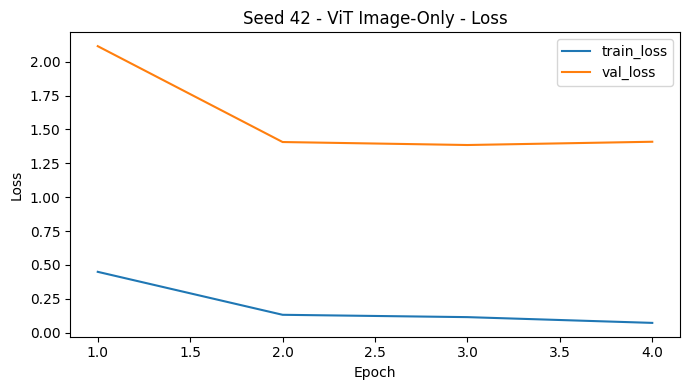

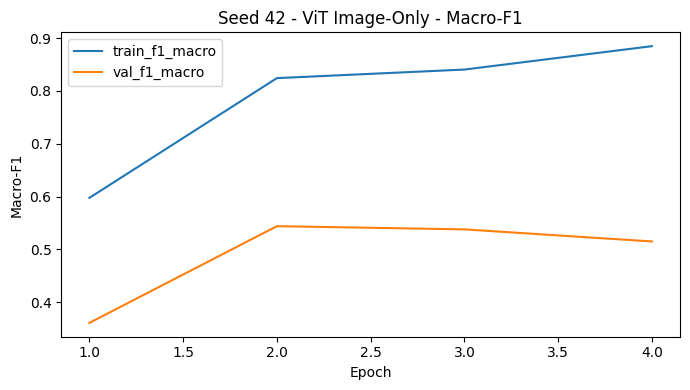


Training model: Prior Fusion | Seed: 42
Parameters: total=91,919,575, trainable=91,919,575
[Seed 42 | Prior Fusion] Epoch 01/6 | train_loss=0.6688 | val_loss=2.4583 | val_f1=0.3121 | rel_loss=0.0000
[Seed 42 | Prior Fusion] Epoch 02/6 | train_loss=0.2676 | val_loss=1.5251 | val_f1=0.4904 | rel_loss=0.0000
[Seed 42 | Prior Fusion] Epoch 03/6 | train_loss=0.1460 | val_loss=1.2147 | val_f1=0.5542 | rel_loss=0.0000
[Seed 42 | Prior Fusion] Epoch 04/6 | train_loss=0.1119 | val_loss=2.1714 | val_f1=0.4424 | rel_loss=0.0000
[Seed 42 | Prior Fusion] Epoch 05/6 | train_loss=0.0824 | val_loss=1.0760 | val_f1=0.5608 | rel_loss=0.0000
[Seed 42 | Prior Fusion] Epoch 06/6 | train_loss=0.0937 | val_loss=1.1151 | val_f1=0.5840 | rel_loss=0.0000


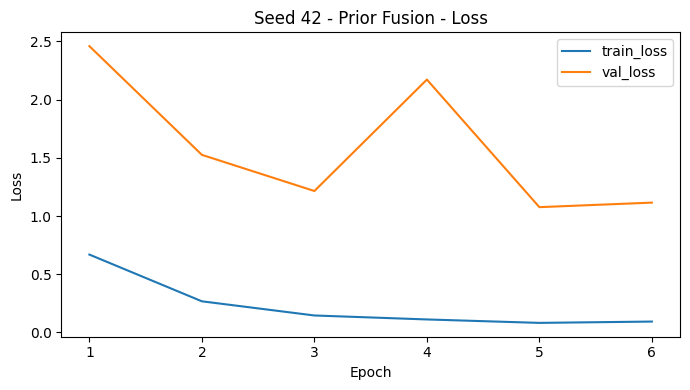

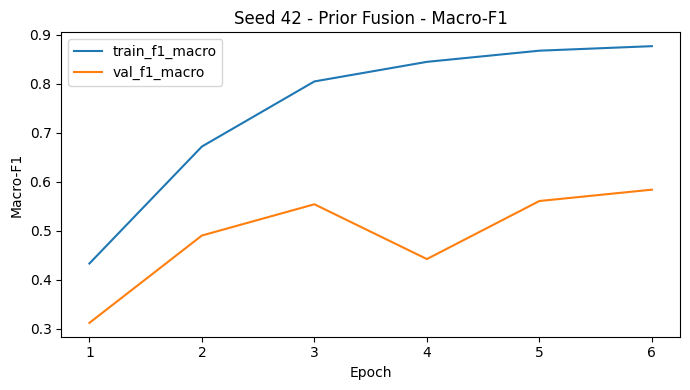


Training model: RG-MF | Seed: 42
Parameters: total=91,919,720, trainable=91,919,720
[Seed 42 | RG-MF] Epoch 01/6 | train_loss=0.6104 | val_loss=2.4431 | val_f1=0.3116 | rel_loss=0.0928
[Seed 42 | RG-MF] Epoch 02/6 | train_loss=0.2093 | val_loss=1.7939 | val_f1=0.4031 | rel_loss=0.0870
[Seed 42 | RG-MF] Epoch 03/6 | train_loss=0.1475 | val_loss=1.3569 | val_f1=0.5330 | rel_loss=0.0771
[Seed 42 | RG-MF] Epoch 04/6 | train_loss=0.0909 | val_loss=1.2351 | val_f1=0.5199 | rel_loss=0.0714
[Seed 42 | RG-MF] Epoch 05/6 | train_loss=0.0954 | val_loss=1.3415 | val_f1=0.5055 | rel_loss=0.0630
[Seed 42 | RG-MF] Early stopping.


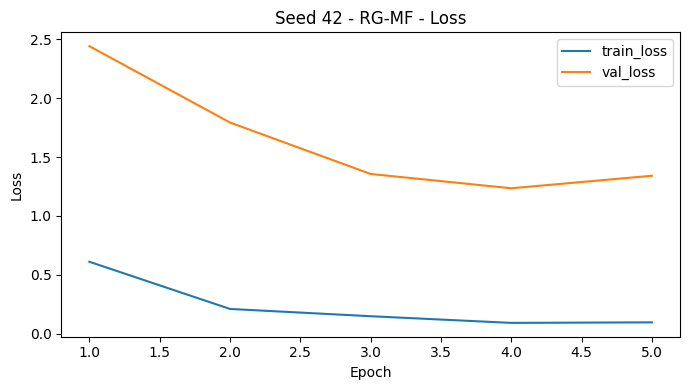

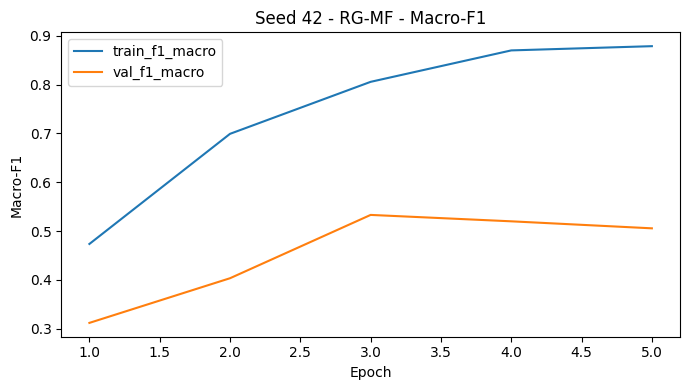


Training model: RG-MF Rule-r* | Seed: 42
Parameters: total=91,919,720, trainable=91,919,720
[Seed 42 | RG-MF Rule-r*] Epoch 01/6 | train_loss=0.6092 | val_loss=2.1911 | val_f1=0.2993 | rel_loss=0.0000
[Seed 42 | RG-MF Rule-r*] Epoch 02/6 | train_loss=0.1990 | val_loss=1.7006 | val_f1=0.4667 | rel_loss=0.0000
[Seed 42 | RG-MF Rule-r*] Epoch 03/6 | train_loss=0.1178 | val_loss=1.1952 | val_f1=0.5613 | rel_loss=0.0000
[Seed 42 | RG-MF Rule-r*] Epoch 04/6 | train_loss=0.1045 | val_loss=1.5200 | val_f1=0.5140 | rel_loss=0.0000
[Seed 42 | RG-MF Rule-r*] Epoch 05/6 | train_loss=0.0791 | val_loss=1.3613 | val_f1=0.4813 | rel_loss=0.0000
[Seed 42 | RG-MF Rule-r*] Early stopping.


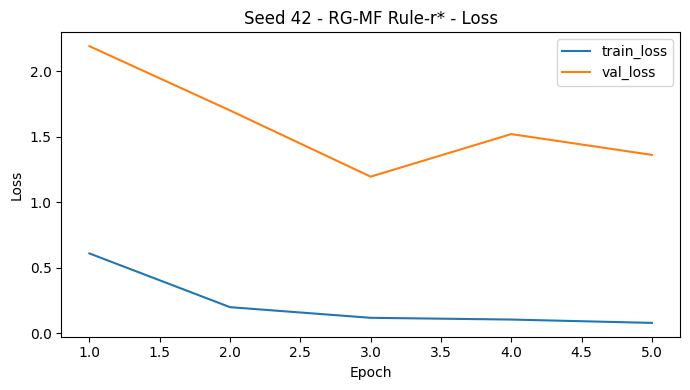

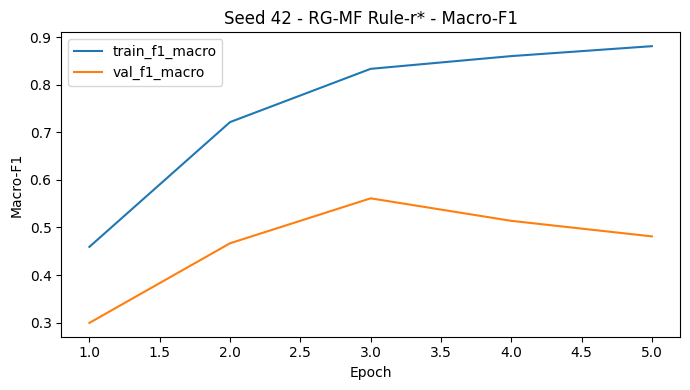


Training model: Metadata-Only | Seed: 42
Parameters: total=2,519, trainable=2,519
[Seed 42 | Metadata-Only] Epoch 01/6 | train_loss=1.8738 | val_loss=2.0052 | val_f1=0.0140 | rel_loss=0.0000
[Seed 42 | Metadata-Only] Epoch 02/6 | train_loss=1.8201 | val_loss=2.0891 | val_f1=0.0031 | rel_loss=0.0000
[Seed 42 | Metadata-Only] Epoch 03/6 | train_loss=1.7629 | val_loss=2.2134 | val_f1=0.0031 | rel_loss=0.0000
[Seed 42 | Metadata-Only] Early stopping.


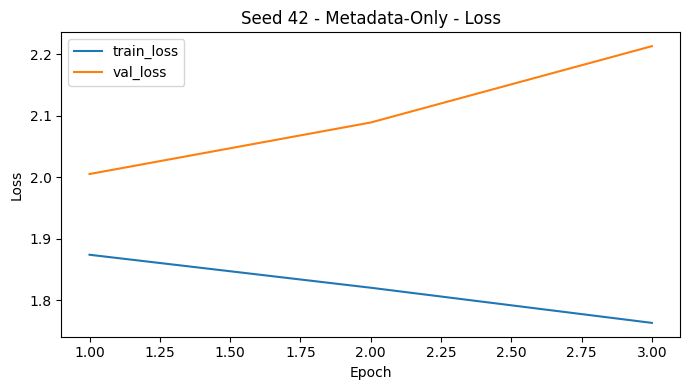

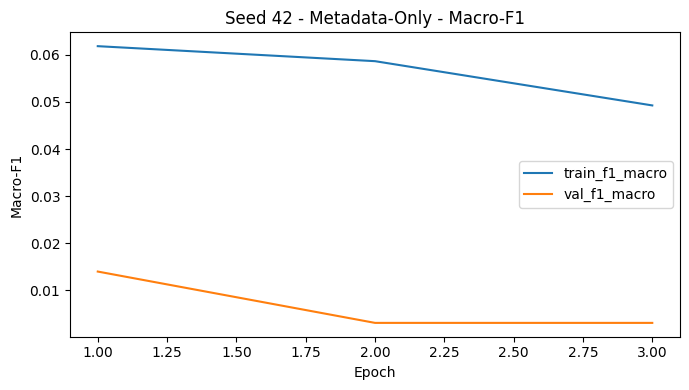


####################################################################################################
STARTING SEED 123
####################################################################################################
[Seed 123] Train=(7061, 9), Val=(1466, 9), Test=(1488, 9)
[Seed 123] Groups train/val/test = 5228/1121/1121

Training model: ViT Image-Only | Seed: 123
Parameters: total=85,997,319, trainable=85,997,319
[Seed 123 | ViT Image-Only] Epoch 01/6 | train_loss=0.3967 | val_loss=1.9999 | val_f1=0.3687 | rel_loss=0.0000
[Seed 123 | ViT Image-Only] Epoch 02/6 | train_loss=0.1586 | val_loss=1.3615 | val_f1=0.5409 | rel_loss=0.0000
[Seed 123 | ViT Image-Only] Epoch 03/6 | train_loss=0.0709 | val_loss=1.1549 | val_f1=0.5904 | rel_loss=0.0000
[Seed 123 | ViT Image-Only] Epoch 04/6 | train_loss=0.0616 | val_loss=1.1871 | val_f1=0.5963 | rel_loss=0.0000
[Seed 123 | ViT Image-Only] Epoch 05/6 | train_loss=0.0409 | val_loss=1.1578 | val_f1=0.6297 | rel_loss=0.0000
[Seed 123 | ViT Image

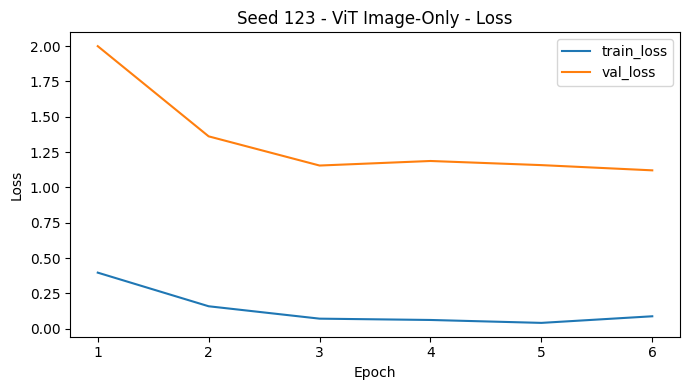

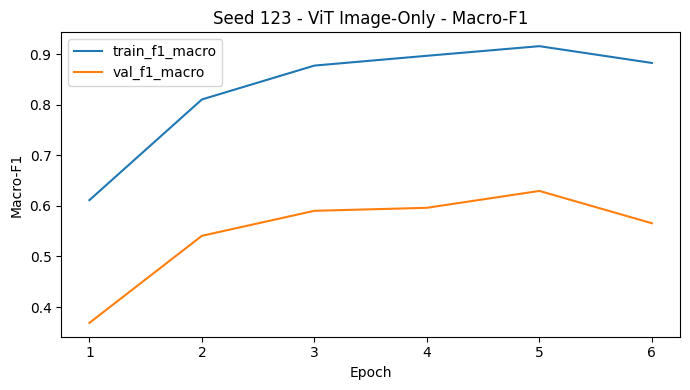


Training model: Prior Fusion | Seed: 123
Parameters: total=91,919,575, trainable=91,919,575
[Seed 123 | Prior Fusion] Epoch 01/6 | train_loss=0.5900 | val_loss=2.4436 | val_f1=0.2603 | rel_loss=0.0000
[Seed 123 | Prior Fusion] Epoch 02/6 | train_loss=0.1825 | val_loss=1.7890 | val_f1=0.4553 | rel_loss=0.0000
[Seed 123 | Prior Fusion] Epoch 03/6 | train_loss=0.1565 | val_loss=1.2693 | val_f1=0.5787 | rel_loss=0.0000
[Seed 123 | Prior Fusion] Epoch 04/6 | train_loss=0.0828 | val_loss=1.4396 | val_f1=0.5562 | rel_loss=0.0000
[Seed 123 | Prior Fusion] Epoch 05/6 | train_loss=0.0742 | val_loss=1.3851 | val_f1=0.5925 | rel_loss=0.0000
[Seed 123 | Prior Fusion] Epoch 06/6 | train_loss=0.0903 | val_loss=1.2945 | val_f1=0.6138 | rel_loss=0.0000


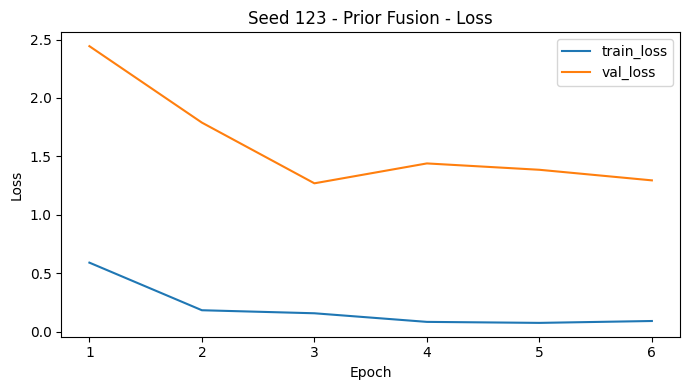

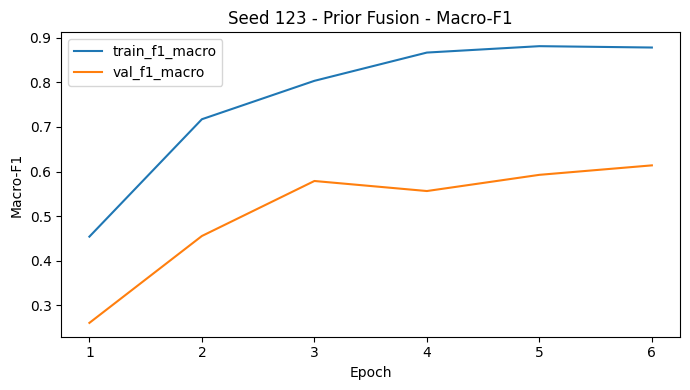


Training model: RG-MF | Seed: 123
Parameters: total=91,919,720, trainable=91,919,720
[Seed 123 | RG-MF] Epoch 01/6 | train_loss=0.6673 | val_loss=2.8591 | val_f1=0.1952 | rel_loss=0.1251
[Seed 123 | RG-MF] Epoch 02/6 | train_loss=0.2630 | val_loss=1.8192 | val_f1=0.4102 | rel_loss=0.1146
[Seed 123 | RG-MF] Epoch 03/6 | train_loss=0.1457 | val_loss=1.3693 | val_f1=0.5284 | rel_loss=0.1013
[Seed 123 | RG-MF] Epoch 04/6 | train_loss=0.1099 | val_loss=1.4521 | val_f1=0.5771 | rel_loss=0.0905
[Seed 123 | RG-MF] Epoch 05/6 | train_loss=0.1265 | val_loss=1.0387 | val_f1=0.6110 | rel_loss=0.0834
[Seed 123 | RG-MF] Epoch 06/6 | train_loss=0.0787 | val_loss=1.2492 | val_f1=0.5667 | rel_loss=0.0750


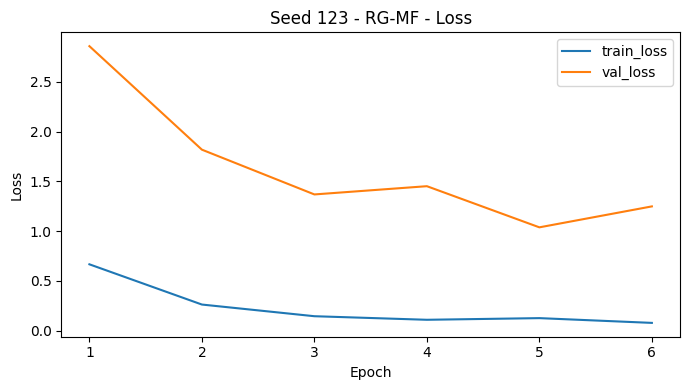

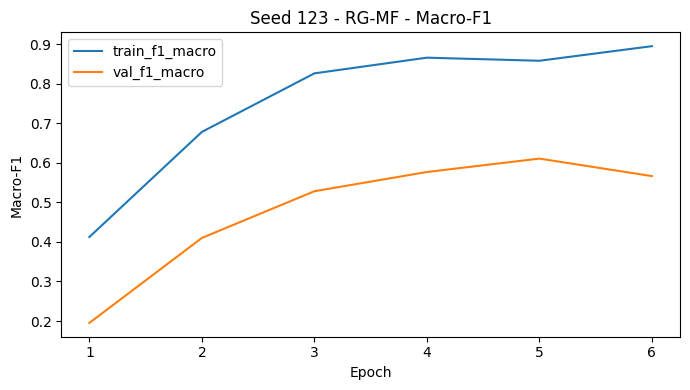


Training model: RG-MF Rule-r* | Seed: 123
Parameters: total=91,919,720, trainable=91,919,720
[Seed 123 | RG-MF Rule-r*] Epoch 01/6 | train_loss=0.6410 | val_loss=2.2234 | val_f1=0.2987 | rel_loss=0.0000
[Seed 123 | RG-MF Rule-r*] Epoch 02/6 | train_loss=0.2089 | val_loss=1.6096 | val_f1=0.4676 | rel_loss=0.0000
[Seed 123 | RG-MF Rule-r*] Epoch 03/6 | train_loss=0.1473 | val_loss=1.0941 | val_f1=0.5966 | rel_loss=0.0000
[Seed 123 | RG-MF Rule-r*] Epoch 04/6 | train_loss=0.0883 | val_loss=1.2821 | val_f1=0.6079 | rel_loss=0.0000
[Seed 123 | RG-MF Rule-r*] Epoch 05/6 | train_loss=0.0896 | val_loss=1.1680 | val_f1=0.5583 | rel_loss=0.0000
[Seed 123 | RG-MF Rule-r*] Epoch 06/6 | train_loss=0.0613 | val_loss=1.0468 | val_f1=0.6082 | rel_loss=0.0000


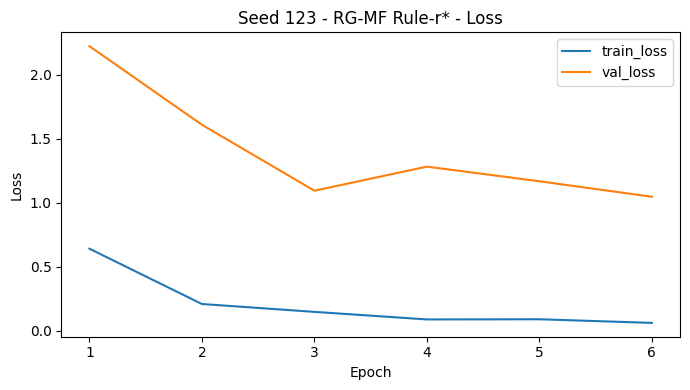

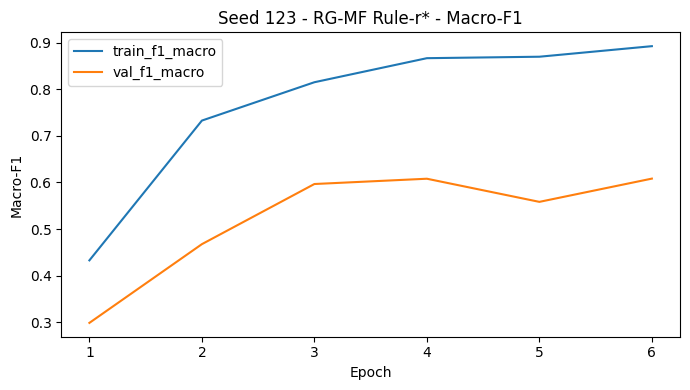


Training model: Metadata-Only | Seed: 123
Parameters: total=2,519, trainable=2,519
[Seed 123 | Metadata-Only] Epoch 01/6 | train_loss=1.9256 | val_loss=1.9477 | val_f1=0.0096 | rel_loss=0.0000
[Seed 123 | Metadata-Only] Epoch 02/6 | train_loss=1.8769 | val_loss=2.0015 | val_f1=0.0031 | rel_loss=0.0000
[Seed 123 | Metadata-Only] Epoch 03/6 | train_loss=1.8288 | val_loss=2.0715 | val_f1=0.0031 | rel_loss=0.0000
[Seed 123 | Metadata-Only] Early stopping.


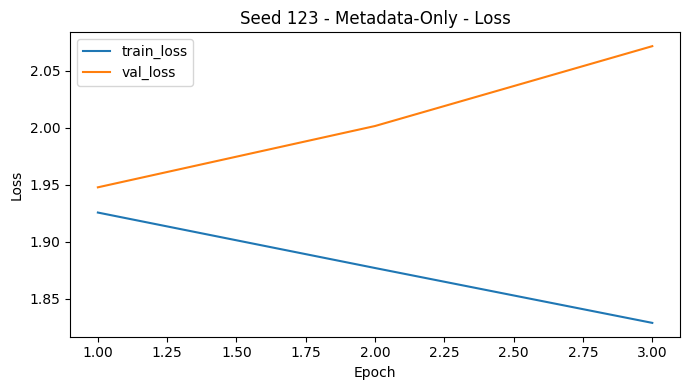

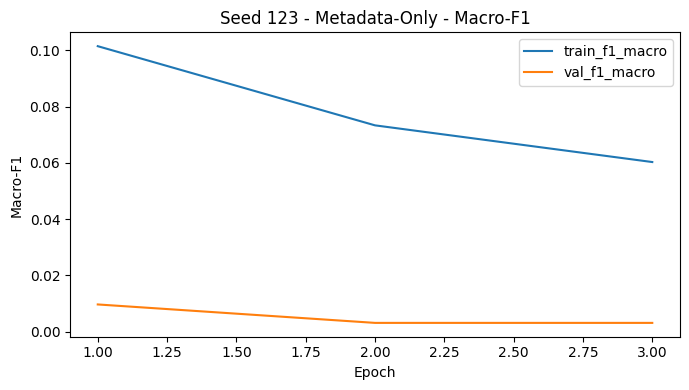


####################################################################################################
STARTING SEED 2025
####################################################################################################
[Seed 2025] Train=(7008, 9), Val=(1512, 9), Test=(1495, 9)
[Seed 2025] Groups train/val/test = 5228/1121/1121

Training model: ViT Image-Only | Seed: 2025
Parameters: total=85,997,319, trainable=85,997,319
[Seed 2025 | ViT Image-Only] Epoch 01/6 | train_loss=0.4494 | val_loss=1.1922 | val_f1=0.5040 | rel_loss=0.0000
[Seed 2025 | ViT Image-Only] Epoch 02/6 | train_loss=0.1278 | val_loss=1.0734 | val_f1=0.5479 | rel_loss=0.0000
[Seed 2025 | ViT Image-Only] Epoch 03/6 | train_loss=0.1017 | val_loss=0.9394 | val_f1=0.5852 | rel_loss=0.0000
[Seed 2025 | ViT Image-Only] Epoch 04/6 | train_loss=0.0591 | val_loss=1.0229 | val_f1=0.6586 | rel_loss=0.0000
[Seed 2025 | ViT Image-Only] Epoch 05/6 | train_loss=0.0626 | val_loss=1.4536 | val_f1=0.5812 | rel_loss=0.0000
[Seed 2025 |

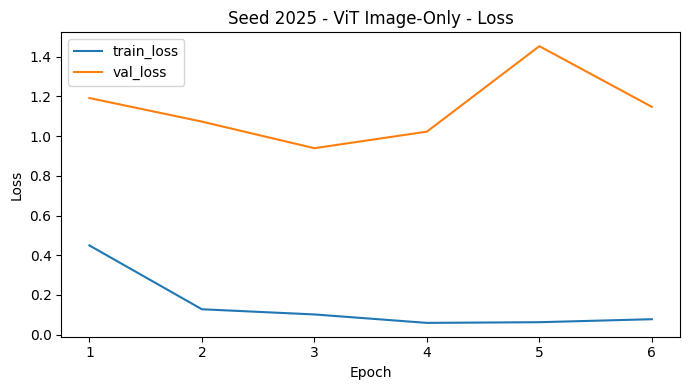

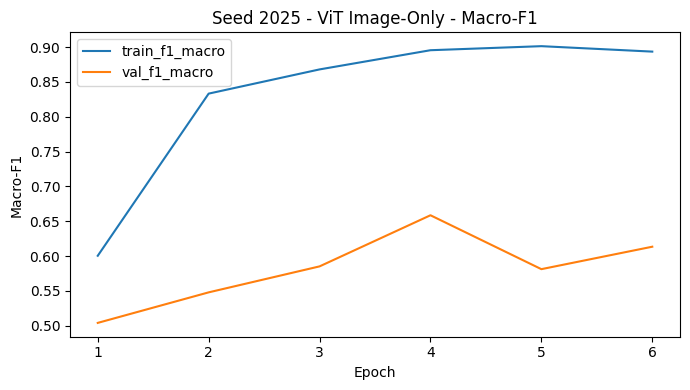


Training model: Prior Fusion | Seed: 2025
Parameters: total=91,919,575, trainable=91,919,575
[Seed 2025 | Prior Fusion] Epoch 01/6 | train_loss=0.5492 | val_loss=2.4129 | val_f1=0.3252 | rel_loss=0.0000
[Seed 2025 | Prior Fusion] Epoch 02/6 | train_loss=0.2087 | val_loss=1.8641 | val_f1=0.4740 | rel_loss=0.0000
[Seed 2025 | Prior Fusion] Epoch 03/6 | train_loss=0.1337 | val_loss=1.6723 | val_f1=0.5035 | rel_loss=0.0000
[Seed 2025 | Prior Fusion] Epoch 04/6 | train_loss=0.0710 | val_loss=1.2775 | val_f1=0.5858 | rel_loss=0.0000
[Seed 2025 | Prior Fusion] Epoch 05/6 | train_loss=0.0858 | val_loss=1.1792 | val_f1=0.5756 | rel_loss=0.0000
[Seed 2025 | Prior Fusion] Epoch 06/6 | train_loss=0.0528 | val_loss=1.1006 | val_f1=0.6192 | rel_loss=0.0000


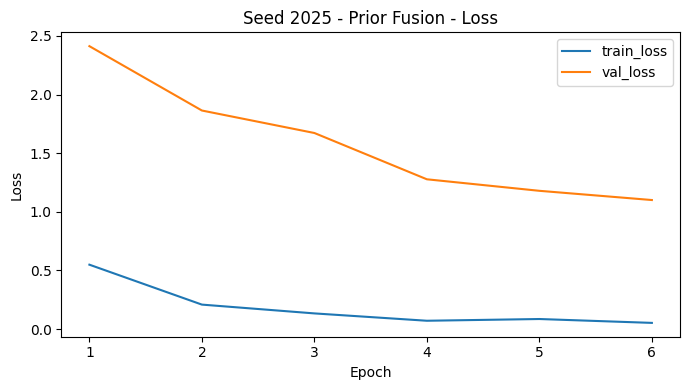

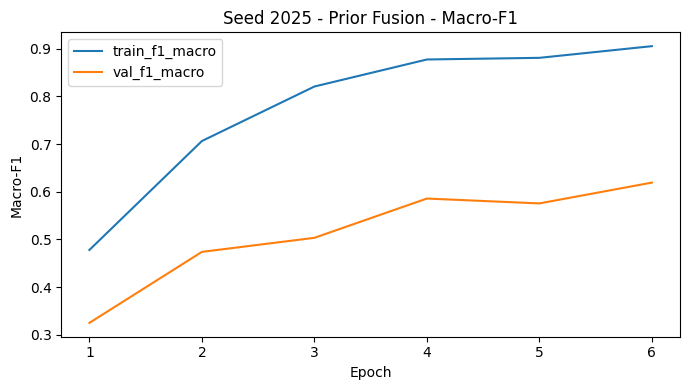


Training model: RG-MF | Seed: 2025
Parameters: total=91,919,720, trainable=91,919,720
[Seed 2025 | RG-MF] Epoch 01/6 | train_loss=0.6703 | val_loss=2.0769 | val_f1=0.4257 | rel_loss=0.1332
[Seed 2025 | RG-MF] Epoch 02/6 | train_loss=0.1872 | val_loss=1.3990 | val_f1=0.5730 | rel_loss=0.1240
[Seed 2025 | RG-MF] Epoch 03/6 | train_loss=0.1297 | val_loss=1.4007 | val_f1=0.5600 | rel_loss=0.1185
[Seed 2025 | RG-MF] Epoch 04/6 | train_loss=0.1236 | val_loss=1.2204 | val_f1=0.5867 | rel_loss=0.1093
[Seed 2025 | RG-MF] Epoch 05/6 | train_loss=0.1219 | val_loss=1.2077 | val_f1=0.5847 | rel_loss=0.0984
[Seed 2025 | RG-MF] Epoch 06/6 | train_loss=0.0608 | val_loss=1.1218 | val_f1=0.6305 | rel_loss=0.0895


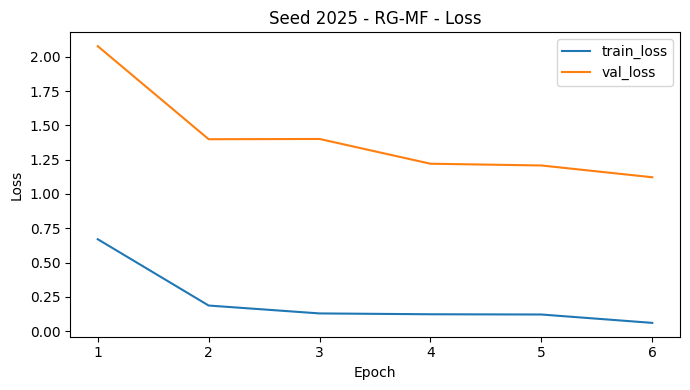

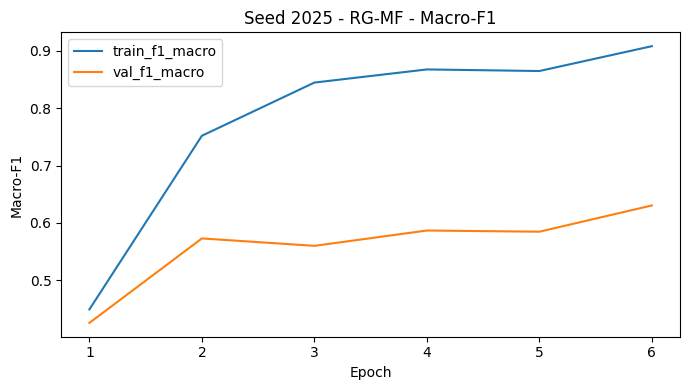


Training model: RG-MF Rule-r* | Seed: 2025
Parameters: total=91,919,720, trainable=91,919,720
[Seed 2025 | RG-MF Rule-r*] Epoch 01/6 | train_loss=0.7144 | val_loss=2.3785 | val_f1=0.3908 | rel_loss=0.0000
[Seed 2025 | RG-MF Rule-r*] Epoch 02/6 | train_loss=0.2296 | val_loss=2.2212 | val_f1=0.3489 | rel_loss=0.0000
[Seed 2025 | RG-MF Rule-r*] Epoch 03/6 | train_loss=0.1313 | val_loss=1.3530 | val_f1=0.5425 | rel_loss=0.0000
[Seed 2025 | RG-MF Rule-r*] Epoch 04/6 | train_loss=0.0892 | val_loss=1.7197 | val_f1=0.5305 | rel_loss=0.0000
[Seed 2025 | RG-MF Rule-r*] Epoch 05/6 | train_loss=0.0685 | val_loss=1.1342 | val_f1=0.5793 | rel_loss=0.0000
[Seed 2025 | RG-MF Rule-r*] Epoch 06/6 | train_loss=0.0592 | val_loss=1.4574 | val_f1=0.5275 | rel_loss=0.0000


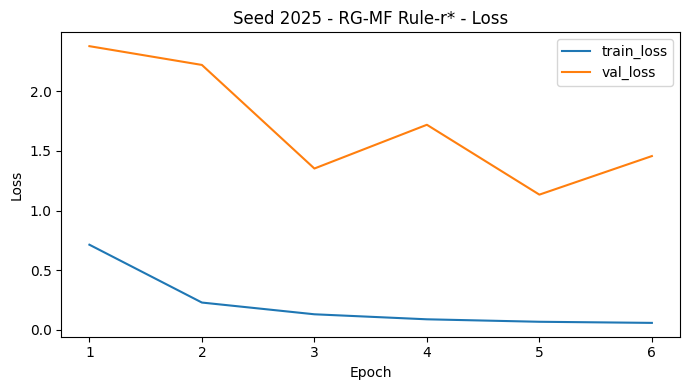

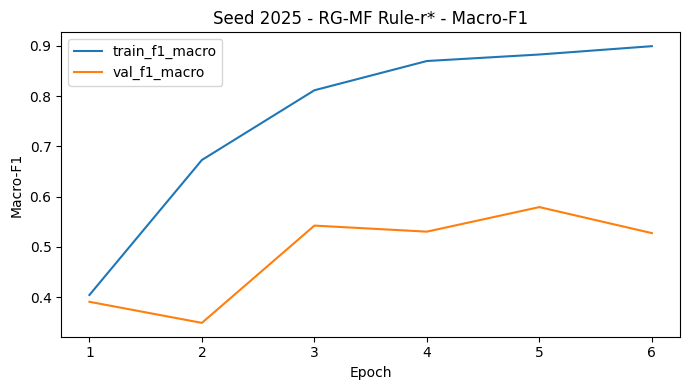


Training model: Metadata-Only | Seed: 2025
Parameters: total=2,519, trainable=2,519
[Seed 2025 | Metadata-Only] Epoch 01/6 | train_loss=1.9697 | val_loss=1.9632 | val_f1=0.0346 | rel_loss=0.0000
[Seed 2025 | Metadata-Only] Epoch 02/6 | train_loss=1.9158 | val_loss=2.0155 | val_f1=0.0036 | rel_loss=0.0000
[Seed 2025 | Metadata-Only] Epoch 03/6 | train_loss=1.8651 | val_loss=2.0746 | val_f1=0.0035 | rel_loss=0.0000
[Seed 2025 | Metadata-Only] Early stopping.


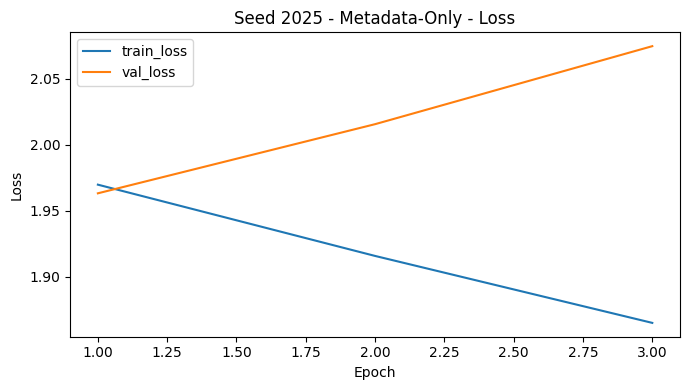

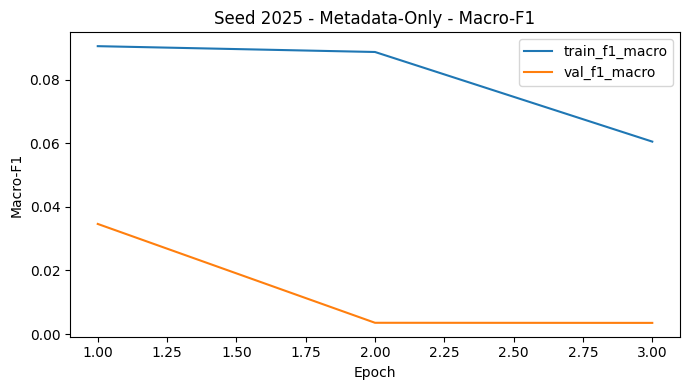

Saved:
/content/ham10000_rg_mf_reviewer3_4_results/all_results_repeated_seed.csv
/content/ham10000_rg_mf_reviewer3_4_results/cost_latency_params.csv
/content/ham10000_rg_mf_reviewer3_4_results/training_histories.csv


,seed,model,stress_type,stress_rate,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,n_samples,mean_r_target,mean_observed_missing,mean_observed_implausibility,mean_reliability,std_reliability,corr_reliability_r_target,corr_reliability_missing,corr_reliability_implausibility,mae_reliability_target,f1_macro_ci95_low,f1_macro_ci95_high
0,42,ViT Image-Only,missing,0.00,0.573273,0.590975,0.719042,0.599803,0.813604,0.573273,0.609962,0.943089,1549,0.986658,0.013342,0.006671,NaN,NaN,NaN,NaN,NaN,NaN,0.556611,0.638726
1,42,ViT Image-Only,missing,0.25,0.573273,0.590975,0.719042,0.599803,0.813604,0.573273,0.609962,0.943089,1549,0.748010,0.251991,0.125995,NaN,NaN,NaN,NaN,NaN,NaN,0.556611,0.638726
2,42,ViT Image-Only,missing,0.50,0.573273,0.590975,0.719042,0.599803,0.813604,0.573273,0.609962,0.943089,1549,0.508500,0.491500,0.245750,NaN,NaN,NaN,NaN,NaN,NaN,0.556611,0.638726
3,42,ViT Image-Only,missing,0.75,0.573273,0.590975,0.719042,0.599803,0.813604,0.573273,0.609962,0.943089,1549,0.253927,0.746073,0.373036,NaN,NaN,NaN,NaN,NaN,NaN,0.556611,0.638726
4,42,ViT Image-Only,corruption,0.00,0.573273,0.590975,0.719042,0.599803,0.813604,0.573273,0.609962,0.943089,1549,0.986658,0.013342,0.006671,NaN,NaN,NaN,NaN,NaN,NaN,0.556611,0.638726


,seed,model,total_params,trainable_params,latency_ms_per_image,latency_images
0,42,ViT Image-Only,85997319,85997319,15.401838,80
1,42,Prior Fusion,91919575,91919575,17.870256,80
2,42,RG-MF,91919720,91919720,21.709234,80
3,42,RG-MF Rule-r*,91919720,91919720,17.291385,80
4,42,Metadata-Only,2519,2519,13.949894,80


In [15]:
# ============================================================
# 10. MAIN REPEATED-SEED EXPERIMENT
# ============================================================
all_results = []
all_histories = []
all_cost_rows = []
prediction_store = {}   # key: (seed, stress_type, rate, model) -> dict(y_true, y_pred, y_prob)
trained_model_store = {}  # optional: keep last trained model references per seed/model

for seed in SEEDS:
    print("\n" + "#" * 100)
    print(f"STARTING SEED {seed}")
    print("#" * 100)

    seed_everything(seed)
    split_info = build_split_for_seed(df, seed)
    train_loader, val_loader, test_clean_loader, stress_loaders = build_datasets_and_loaders(split_info, seed)
    criterion = build_criterion(LOSS_MODE, split_info["df_train"], DEVICE)

    for model_name in MODELS_TO_RUN:
        print("\n" + "=" * 90)
        print(f"Training model: {model_name} | Seed: {seed}")
        print("=" * 90)

        seed_everything(seed)
        model = build_model(model_name, split_info)

        total_params, trainable_params = count_parameters(model)
        print(f"Parameters: total={total_params:,}, trainable={trainable_params:,}")

        model, history_df = fit_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            model_name=model_name,
            criterion=criterion,
            seed=seed,
            epochs=EPOCHS,
            lr=LR,
            wd=WEIGHT_DECAY,
        )
        all_histories.append(history_df)
        trained_model_store[(seed, model_name)] = model

        # Cost indicator: latency on clean test loader.
        latency_ms, latency_images = measure_latency(model, test_clean_loader)
        all_cost_rows.append({
            "seed": seed,
            "model": model_name,
            "total_params": total_params,
            "trainable_params": trainable_params,
            "latency_ms_per_image": latency_ms,
            "latency_images": latency_images,
        })

        # Evaluate clean and stress conditions.
        for stress_type in STRESS_TYPES:
            for rate in STRESS_RATES:
                loader = stress_loaders[(stress_type, rate)]
                metrics, y_true, y_pred, y_prob, aux_arrays = evaluate_loader(model, loader)

                ci_lo, ci_hi = bootstrap_ci_metric(y_true, y_pred, metric="f1_macro", n_boot=N_BOOTSTRAP, seed=seed + 123)
                metrics["f1_macro_ci95_low"] = ci_lo
                metrics["f1_macro_ci95_high"] = ci_hi

                row = {
                    "seed": seed,
                    "model": model_name,
                    "stress_type": stress_type,
                    "stress_rate": rate,
                    **metrics,
                }
                all_results.append(row)

                if SAVE_PREDICTIONS:
                    prediction_store[(seed, stress_type, rate, model_name)] = {
                        "y_true": y_true,
                        "y_pred": y_pred,
                        "y_prob": y_prob,
                        "aux": aux_arrays,
                    }

        # Optional plot per training run.
        plot_history(history_df, f"Seed {seed} - {model_name}")

        # Save partial after each model.
        pd.DataFrame(all_results).to_csv(SAVE_DIR / "all_results_partial.csv", index=False)
        pd.DataFrame(all_cost_rows).to_csv(SAVE_DIR / "cost_partial.csv", index=False)

        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results)
cost_df = pd.DataFrame(all_cost_rows)
histories_df = pd.concat([h for h in all_histories if h is not None and not h.empty], ignore_index=True) if all_histories else pd.DataFrame()

results_df.to_csv(SAVE_DIR / "all_results_repeated_seed.csv", index=False)
cost_df.to_csv(SAVE_DIR / "cost_latency_params.csv", index=False)
histories_df.to_csv(SAVE_DIR / "training_histories.csv", index=False)

print("Saved:")
print(SAVE_DIR / "all_results_repeated_seed.csv")
print(SAVE_DIR / "cost_latency_params.csv")
print(SAVE_DIR / "training_histories.csv")

display(results_df.head())
display(cost_df.head())

## 11. Mean ± SD, 95% CI across seeds, dan degradation summary

Bagian ini menghasilkan tabel utama untuk paper revisi.

In [16]:
# ============================================================
# 11. AGGREGATE RESULTS ACROSS SEEDS
# ============================================================
results_df = pd.read_csv(SAVE_DIR / "all_results_repeated_seed.csv")
cost_df = pd.read_csv(SAVE_DIR / "cost_latency_params.csv")

summary_rows = []
for (model, stress_type, rate), grp in results_df.groupby(["model", "stress_type", "stress_rate"]):
    vals = grp["f1_macro"].values
    accs = grp["accuracy"].values
    row = {
        "model": model,
        "stress_type": stress_type,
        "stress_rate": rate,
        "f1_macro_mean": np.mean(vals),
        "f1_macro_std": np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
        "f1_macro_ci95": 1.96 * (np.std(vals, ddof=1) / math.sqrt(len(vals))) if len(vals) > 1 else np.nan,
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs, ddof=1) if len(accs) > 1 else np.nan,
        "n_seeds": len(vals),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SAVE_DIR / "table_repeated_seed_mean_std_ci.csv", index=False)

display(summary_df.sort_values(["stress_type", "stress_rate", "model"]).round(4))

# Degradation: clean -> severe 0.75.
degradation_rows = []
for seed in SEEDS:
    for stress_type in STRESS_TYPES:
        temp = results_df[(results_df["seed"] == seed) & (results_df["stress_type"] == stress_type)]
        clean = temp[temp["stress_rate"] == 0.0][["model", "f1_macro"]].rename(columns={"f1_macro": "clean_f1"})
        severe = temp[temp["stress_rate"] == 0.75][["model", "f1_macro"]].rename(columns={"f1_macro": "severe_f1"})
        merged = clean.merge(severe, on="model")
        merged["seed"] = seed
        merged["stress_type"] = stress_type
        merged["drop_f1"] = merged["severe_f1"] - merged["clean_f1"]
        degradation_rows.append(merged)

degradation_df = pd.concat(degradation_rows, ignore_index=True)
degradation_summary = (
    degradation_df
    .groupby(["model", "stress_type"])
    .agg(
        clean_f1_mean=("clean_f1", "mean"),
        severe_f1_mean=("severe_f1", "mean"),
        drop_f1_mean=("drop_f1", "mean"),
        drop_f1_std=("drop_f1", "std"),
    )
    .reset_index()
)
degradation_df.to_csv(SAVE_DIR / "degradation_by_seed.csv", index=False)
degradation_summary.to_csv(SAVE_DIR / "table_degradation_summary.csv", index=False)

print("Degradation summary: clean -> 0.75")
display(degradation_summary.round(4))

,model,stress_type,stress_rate,f1_macro_mean,f1_macro_std,f1_macro_ci95,accuracy_mean,accuracy_std,n_seeds
0,Metadata-Only,corruption,0.00,0.0198,0.0194,0.0219,0.0267,0.0149,3
8,Prior Fusion,corruption,0.00,0.6142,0.0438,0.0496,0.6184,0.0426,3
16,RG-MF,corruption,0.00,0.6121,0.0261,0.0295,0.6433,0.0498,3
24,RG-MF Rule-r*,corruption,0.00,0.6103,0.0326,0.0369,0.6395,0.0032,3
32,ViT Image-Only,corruption,0.00,0.6190,0.0379,0.0429,0.6181,0.0458,3
1,Metadata-Only,corruption,0.25,0.0202,0.0183,0.0208,0.0310,0.0218,3
9,Prior Fusion,corruption,0.25,0.6125,0.0436,0.0493,0.6179,0.0423,3
17,RG-MF,corruption,0.25,0.6119,0.0261,0.0296,0.6433,0.0498,3
25,RG-MF Rule-r*,corruption,0.25,0.6098,0.0317,0.0359,0.6397,0.0034,3
33,ViT Image-Only,corruption,0.25,0.6190,0.0379,0.0429,0.6181,0.0458,3


Degradation summary: clean -> 0.75


,model,stress_type,clean_f1_mean,severe_f1_mean,drop_f1_mean,drop_f1_std
0,Metadata-Only,corruption,0.0198,0.0216,0.0019,0.0012
1,Metadata-Only,missing,0.0198,0.0186,-0.0012,0.0033
2,Prior Fusion,corruption,0.6142,0.6129,-0.0013,0.0008
3,Prior Fusion,missing,0.6142,0.6127,-0.0015,0.0022
4,RG-MF,corruption,0.6121,0.6110,-0.0010,0.0038
5,RG-MF,missing,0.6121,0.6104,-0.0017,0.0032
6,RG-MF Rule-r*,corruption,0.6103,0.6085,-0.0017,0.0023
7,RG-MF Rule-r*,missing,0.6103,0.6085,-0.0017,0.0021
8,ViT Image-Only,corruption,0.6190,0.6190,0.0000,0.0000
9,ViT Image-Only,missing,0.6190,0.6190,0.0000,0.0000


## 12. Paired bootstrap significance: RG-MF vs Prior Fusion

Reviewer 2 meminta significance testing. Cell ini menghitung paired bootstrap test pada prediksi paired di test set yang sama.

In [17]:
# ============================================================
# 12. PAIRED BOOTSTRAP SIGNIFICANCE TEST
# ============================================================
# Jika kernel restart, prediction_store hilang. Cell ini perlu dijalankan setelah main experiment dalam sesi yang sama.
# Untuk workflow jangka panjang, prediction arrays dapat disimpan ke npz. Di sini disimpan saat SAVE_PREDICTIONS=True.

significance_rows = []

if "prediction_store" not in globals() or len(prediction_store) == 0:
    print("prediction_store tidak ditemukan. Jalankan Cell 10 terlebih dahulu dalam sesi yang sama.")
else:
    for seed in SEEDS:
        for stress_type in STRESS_TYPES:
            for rate in STRESS_RATES:
                key_rg = (seed, stress_type, rate, "RG-MF")
                key_pf = (seed, stress_type, rate, "Prior Fusion")

                if key_rg not in prediction_store or key_pf not in prediction_store:
                    continue

                y_true = prediction_store[key_rg]["y_true"]
                pred_rg = prediction_store[key_rg]["y_pred"]
                pred_pf = prediction_store[key_pf]["y_pred"]

                obs, lo, hi, p = paired_bootstrap_test(
                    y_true=y_true,
                    pred_a=pred_rg,
                    pred_b=pred_pf,
                    metric="f1_macro",
                    n_boot=N_BOOTSTRAP,
                    seed=seed + 999,
                )
                significance_rows.append({
                    "seed": seed,
                    "stress_type": stress_type,
                    "stress_rate": rate,
                    "comparison": "RG-MF minus Prior Fusion",
                    "metric": "macro-F1",
                    "observed_diff": obs,
                    "ci95_low": lo,
                    "ci95_high": hi,
                    "p_value_two_sided": p,
                })

significance_df = pd.DataFrame(significance_rows)
if not significance_df.empty:
    significance_df.to_csv(SAVE_DIR / "table_paired_bootstrap_significance.csv", index=False)
    display(significance_df.round(5))
else:
    print("No significance rows produced.")

,seed,stress_type,stress_rate,comparison,metric,observed_diff,ci95_low,ci95_high,p_value_two_sided
0,42,missing,0.00,RG-MF minus Prior Fusion,macro-F1,-0.04527,-0.08211,-0.00700,0.028
1,42,missing,0.25,RG-MF minus Prior Fusion,macro-F1,-0.04499,-0.08145,-0.00651,0.028
2,42,missing,0.50,RG-MF minus Prior Fusion,macro-F1,-0.04513,-0.08091,-0.00663,0.028
3,42,missing,0.75,RG-MF minus Prior Fusion,macro-F1,-0.04504,-0.08117,-0.00664,0.032
4,42,corruption,0.00,RG-MF minus Prior Fusion,macro-F1,-0.04527,-0.08211,-0.00700,0.028
5,42,corruption,0.25,RG-MF minus Prior Fusion,macro-F1,-0.04424,-0.08006,-0.00572,0.036
6,42,corruption,0.50,RG-MF minus Prior Fusion,macro-F1,-0.04470,-0.08092,-0.00611,0.032
7,42,corruption,0.75,RG-MF minus Prior Fusion,macro-F1,-0.05009,-0.08882,-0.01152,0.024
8,123,missing,0.00,RG-MF minus Prior Fusion,macro-F1,0.04213,-0.01038,0.09624,0.104
9,123,missing,0.25,RG-MF minus Prior Fusion,macro-F1,0.04385,-0.01117,0.09733,0.092


## 13. Reliability verification: apakah `r` benar-benar mengikuti kualitas metadata?

Reviewer 2 menanyakan bukti bahwa learned `r` berkorelasi dengan missingness/corruption. Cell ini mengekstrak:
- mean learned reliability,
- mean metadata-quality target,
- correlation `r` vs `r_target`,
- correlation `r` vs observed missingness,
- correlation `r` vs observed implausibility.

,stress_type,stress_rate,mean_reliability,std_reliability_across_seeds,mean_r_target,corr_r_target_mean,corr_missing_mean,corr_implausibility_mean,mae_r_target_mean,f1_macro_mean
0,corruption,0.00,0.6059,0.0154,0.9897,0.9615,-0.9615,-0.9615,0.3879,0.6121
1,corruption,0.25,0.5995,0.0164,0.8968,0.8364,-0.3506,-0.8127,0.3118,0.6119
2,corruption,0.50,0.5927,0.0177,0.8009,0.8285,-0.2068,-0.8194,0.2528,0.6127
3,corruption,0.75,0.5858,0.0186,0.7061,0.8140,-0.1546,-0.8090,0.2103,0.6110
4,missing,0.00,0.6059,0.0154,0.9897,0.9615,-0.9615,-0.9615,0.3879,0.6121
5,missing,0.25,0.5854,0.0159,0.7452,0.7495,-0.7495,-0.7495,0.2426,0.6121
6,missing,0.50,0.5674,0.0216,0.4995,0.7049,-0.7049,-0.7049,0.2339,0.6101
7,missing,0.75,0.5509,0.0280,0.2549,0.6758,-0.6758,-0.6758,0.3370,0.6104


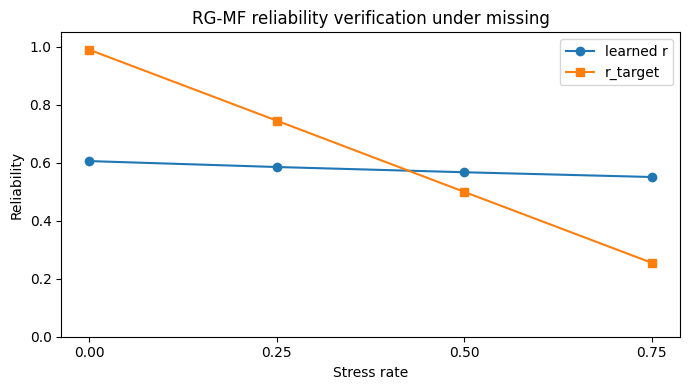

Saved: /content/ham10000_rg_mf_reviewer3_4_results/fig_reliability_missing.png


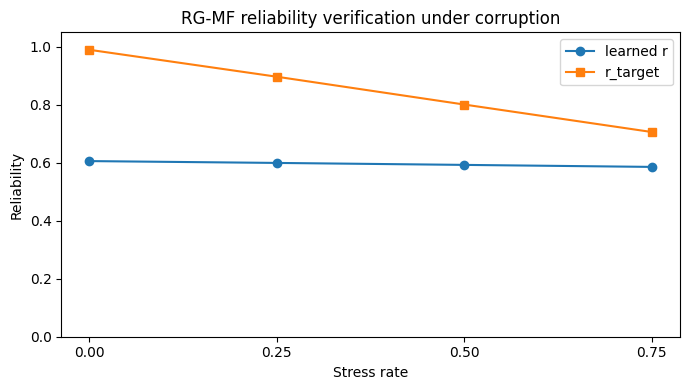

Saved: /content/ham10000_rg_mf_reviewer3_4_results/fig_reliability_corruption.png


In [18]:
# ============================================================
# 13. RELIABILITY VERIFICATION SUMMARY
# ============================================================
results_df = pd.read_csv(SAVE_DIR / "all_results_repeated_seed.csv")

rel_cols = [
    "seed", "model", "stress_type", "stress_rate",
    "mean_reliability", "std_reliability", "mean_r_target",
    "mean_observed_missing", "mean_observed_implausibility",
    "corr_reliability_r_target",
    "corr_reliability_missing",
    "corr_reliability_implausibility",
    "mae_reliability_target",
    "f1_macro",
    "accuracy",
]

reliability_df = results_df[results_df["model"] == "RG-MF"][rel_cols].copy()
reliability_df.to_csv(SAVE_DIR / "reliability_verification_by_seed.csv", index=False)

reliability_summary = (
    reliability_df
    .groupby(["stress_type", "stress_rate"])
    .agg(
        mean_reliability=("mean_reliability", "mean"),
        std_reliability_across_seeds=("mean_reliability", "std"),
        mean_r_target=("mean_r_target", "mean"),
        corr_r_target_mean=("corr_reliability_r_target", "mean"),
        corr_missing_mean=("corr_reliability_missing", "mean"),
        corr_implausibility_mean=("corr_reliability_implausibility", "mean"),
        mae_r_target_mean=("mae_reliability_target", "mean"),
        f1_macro_mean=("f1_macro", "mean"),
    )
    .reset_index()
)
reliability_summary.to_csv(SAVE_DIR / "table_reliability_verification_summary.csv", index=False)

display(reliability_summary.round(4))

# Plot mean reliability vs stress rate.
for stress_type in STRESS_TYPES:
    temp = reliability_summary[reliability_summary["stress_type"] == stress_type].copy()
    plt.figure(figsize=(7, 4))
    plt.plot(temp["stress_rate"], temp["mean_reliability"], marker="o", label="learned r")
    plt.plot(temp["stress_rate"], temp["mean_r_target"], marker="s", label="r_target")
    plt.title(f"RG-MF reliability verification under {stress_type}")
    plt.xlabel("Stress rate")
    plt.ylabel("Reliability")
    plt.xticks(STRESS_RATES)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    fig_path = SAVE_DIR / f"fig_reliability_{stress_type}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print("Saved:", fig_path)

## 14. Inference ablation of reliability cues

Ablation ini tidak membutuhkan retraining. Tujuannya menjawab kritik Reviewer 2 bahwa availability dan plausibility cues belum diisolasi. Untuk model RG-MF yang sama, kita evaluasi ulang dengan mode:
- `full`
- `availability_only`
- `plausibility_only`
- `no_gate`
- `static_mean`

Catatan: ini adalah **inference cue ablation**, bukan training ablation. Jika waktu cukup, training ablation juga bisa ditambahkan, tetapi versi ini sudah memberi bukti sensitivitas mekanisme gate.

In [19]:
# ============================================================
# 14. INFERENCE ABLATION OF RELIABILITY CUES
# ============================================================
gate_modes = ["full", "rule_rstar", "availability_only", "plausibility_only", "no_gate", "static_mean", "zero_metadata"]
ablation_rows = []

for seed in SEEDS:
    print("\nAblation seed:", seed)
    split_info = build_split_for_seed(df, seed)
    _, _, test_clean_loader, stress_loaders = build_datasets_and_loaders(split_info, seed)

    model = build_model("RG-MF", split_info).to(DEVICE)
    ckpt = checkpoint_path(seed, "RG-MF")
    if not ckpt.exists():
        print(f"Checkpoint not found for seed {seed}: {ckpt}. Skip.")
        continue

    state = torch.load(ckpt, map_location=DEVICE)
    model.load_state_dict(state["model_state_dict"])
    model.eval()

    for gate_mode in gate_modes:
        for stress_type in STRESS_TYPES:
            for rate in STRESS_RATES:
                loader = stress_loaders[(stress_type, rate)]
                metrics, y_true, y_pred, y_prob, aux_arrays = evaluate_loader(model, loader, gate_mode=gate_mode)
                ablation_rows.append({
                    "seed": seed,
                    "gate_mode": gate_mode,
                    "stress_type": stress_type,
                    "stress_rate": rate,
                    "accuracy": metrics["accuracy"],
                    "f1_macro": metrics["f1_macro"],
                    "mean_reliability": metrics["mean_reliability"],
                    "mean_r_target": metrics["mean_r_target"],
                    "corr_reliability_r_target": metrics["corr_reliability_r_target"],
                })

    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

ablation_df = pd.DataFrame(ablation_rows)
if not ablation_df.empty:
    ablation_df.to_csv(SAVE_DIR / "table_rg_mf_inference_cue_ablation_by_seed.csv", index=False)

    ablation_summary = (
        ablation_df
        .groupby(["gate_mode", "stress_type", "stress_rate"])
        .agg(
            f1_macro_mean=("f1_macro", "mean"),
            f1_macro_std=("f1_macro", "std"),
            accuracy_mean=("accuracy", "mean"),
            mean_reliability=("mean_reliability", "mean"),
            corr_reliability_r_target=("corr_reliability_r_target", "mean"),
        )
        .reset_index()
    )
    ablation_summary.to_csv(SAVE_DIR / "table_rg_mf_inference_cue_ablation_summary.csv", index=False)
    display(ablation_summary.round(4))
else:
    print("No ablation results produced.")


Ablation seed: 42
[Seed 42] Train=(7000, 9), Val=(1466, 9), Test=(1549, 9)
[Seed 42] Groups train/val/test = 5228/1121/1121

Ablation seed: 123
[Seed 123] Train=(7061, 9), Val=(1466, 9), Test=(1488, 9)
[Seed 123] Groups train/val/test = 5228/1121/1121

Ablation seed: 2025
[Seed 2025] Train=(7008, 9), Val=(1512, 9), Test=(1495, 9)
[Seed 2025] Groups train/val/test = 5228/1121/1121


,gate_mode,stress_type,stress_rate,f1_macro_mean,f1_macro_std,accuracy_mean,mean_reliability,corr_reliability_r_target
0,availability_only,corruption,0.00,0.6119,0.0261,0.6433,0.5503,0.9246
1,availability_only,corruption,0.25,0.6115,0.0263,0.6430,0.5505,0.3148
2,availability_only,corruption,0.50,0.6123,0.0259,0.6435,0.5507,0.1881
3,availability_only,corruption,0.75,0.6106,0.0284,0.6433,0.5508,0.1236
4,availability_only,missing,0.00,0.6119,0.0261,0.6433,0.5503,0.9246
5,availability_only,missing,0.25,0.6119,0.0261,0.6433,0.5353,0.6177
6,availability_only,missing,0.50,0.6101,0.0269,0.6432,0.5231,0.5366
7,availability_only,missing,0.75,0.6104,0.0268,0.6435,0.5124,0.4919
8,full,corruption,0.00,0.6121,0.0261,0.6433,0.6059,0.9615
9,full,corruption,0.25,0.6119,0.0261,0.6433,0.5995,0.8364


## 15. Reviewer 3/4 additional analyses: rule-based r* gate, metadata contribution, and targeted non-MCAR stress

Cell berikut menambahkan analisis yang secara langsung menjawab komentar reviewer terbaru:

- **Rule-based r\* gate**: membandingkan learned RG-MF dengan aturan langsung `M_g = r* M`.
- **Zero-metadata gate**: mengukur apakah model didominasi citra dengan mematikan metadata saat inference.
- **Modality norm probe**: mengukur besarnya representasi metadata setelah gating relatif terhadap representasi visual.
- **Targeted non-MCAR stress**: stress metadata berbasis kondisi, bukan hanya MCAR/random nested masks.


In [20]:
# ============================================================
# 15A. REVIEWER 3/4: GATE COMPARISON AND METADATA CONTRIBUTION ANALYSIS
# ============================================================
# Output utama:
# - table_reviewer34_gate_probe_by_seed.csv
# - table_reviewer34_gate_probe_summary.csv
# - table_metadata_contribution_clean_to_zero_summary.csv

if RUN_METADATA_CONTRIBUTION_ANALYSIS:
    gate_probe_modes = ["full", "rule_rstar", "no_gate", "static_mean", "zero_metadata"]
    gate_probe_conditions = [
        ("missing", 0.0),
        ("missing", 0.75),
        ("corruption", 0.75),
    ]
    gate_probe_rows = []

    for seed in SEEDS:
        print("\n[Gate probe] seed:", seed)
        split_info = build_split_for_seed(df, seed)
        _, _, test_clean_loader, stress_loaders = build_datasets_and_loaders(split_info, seed)

        model = build_model("RG-MF", split_info).to(DEVICE)
        ckpt = checkpoint_path(seed, "RG-MF")
        if not ckpt.exists():
            print(f"[SKIP] RG-MF checkpoint not found: {ckpt}")
            continue
        state = torch.load(ckpt, map_location=DEVICE)
        model.load_state_dict(state["model_state_dict"])
        model.eval()

        for gate_mode in gate_probe_modes:
            for stress_type, rate in gate_probe_conditions:
                loader = stress_loaders[(stress_type, rate)]
                metrics, y_true, y_pred, y_prob, aux_arrays = evaluate_loader(model, loader, gate_mode=gate_mode)
                gate_probe_rows.append({
                    "seed": seed,
                    "base_model": "RG-MF checkpoint",
                    "gate_mode": gate_mode,
                    "stress_type": stress_type,
                    "stress_rate": rate,
                    "accuracy": metrics["accuracy"],
                    "f1_macro": metrics["f1_macro"],
                    "mean_reliability": metrics["mean_reliability"],
                    "mean_r_target": metrics["mean_r_target"],
                    "corr_reliability_r_target": metrics["corr_reliability_r_target"],
                })

        del model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    gate_probe_df = pd.DataFrame(gate_probe_rows)
    if not gate_probe_df.empty:
        gate_probe_df.to_csv(SAVE_DIR / "table_reviewer34_gate_probe_by_seed.csv", index=False)
        gate_probe_summary = (
            gate_probe_df
            .groupby(["gate_mode", "stress_type", "stress_rate"])
            .agg(
                f1_macro_mean=("f1_macro", "mean"),
                f1_macro_std=("f1_macro", "std"),
                accuracy_mean=("accuracy", "mean"),
                mean_reliability=("mean_reliability", "mean"),
                mean_r_target=("mean_r_target", "mean"),
                corr_reliability_r_target=("corr_reliability_r_target", "mean"),
            )
            .reset_index()
        )
        gate_probe_summary.to_csv(SAVE_DIR / "table_reviewer34_gate_probe_summary.csv", index=False)
        display(gate_probe_summary.round(4))

        # Contribution summary: full gate minus zero metadata.
        piv = gate_probe_df.pivot_table(
            index=["seed", "stress_type", "stress_rate"], columns="gate_mode", values="f1_macro"
        ).reset_index()
        if "full" in piv.columns and "zero_metadata" in piv.columns:
            piv["delta_full_minus_zero_metadata"] = piv["full"] - piv["zero_metadata"]
            contrib_summary = (
                piv.groupby(["stress_type", "stress_rate"])
                .agg(
                    delta_f1_mean=("delta_full_minus_zero_metadata", "mean"),
                    delta_f1_std=("delta_full_minus_zero_metadata", "std"),
                    full_f1_mean=("full", "mean"),
                    zero_metadata_f1_mean=("zero_metadata", "mean"),
                )
                .reset_index()
            )
            contrib_summary.to_csv(SAVE_DIR / "table_metadata_contribution_clean_to_zero_summary.csv", index=False)
            print("Metadata contribution summary: full gate minus zero-metadata gate")
            display(contrib_summary.round(4))
    else:
        print("No gate probe results produced. Run the main experiment first or check RG-MF checkpoints.")
else:
    print("RUN_METADATA_CONTRIBUTION_ANALYSIS=False")



[Gate probe] seed: 42
[Seed 42] Train=(7000, 9), Val=(1466, 9), Test=(1549, 9)
[Seed 42] Groups train/val/test = 5228/1121/1121

[Gate probe] seed: 123
[Seed 123] Train=(7061, 9), Val=(1466, 9), Test=(1488, 9)
[Seed 123] Groups train/val/test = 5228/1121/1121

[Gate probe] seed: 2025
[Seed 2025] Train=(7008, 9), Val=(1512, 9), Test=(1495, 9)
[Seed 2025] Groups train/val/test = 5228/1121/1121


,gate_mode,stress_type,stress_rate,f1_macro_mean,f1_macro_std,accuracy_mean,mean_reliability,mean_r_target,corr_reliability_r_target
0,full,corruption,0.75,0.6110,0.0283,0.6435,0.5858,0.7061,0.8140
1,full,missing,0.00,0.6121,0.0261,0.6433,0.6059,0.9897,0.9615
2,full,missing,0.75,0.6104,0.0268,0.6435,0.5509,0.2549,0.6758
3,no_gate,corruption,0.75,0.6106,0.0284,0.6422,1.0000,0.7061,NaN
4,no_gate,missing,0.00,0.6119,0.0262,0.6430,1.0000,0.9897,NaN
5,no_gate,missing,0.75,0.6103,0.0269,0.6428,1.0000,0.2549,NaN
6,rule_rstar,corruption,0.75,0.6106,0.0283,0.6426,0.7061,0.7061,1.0000
7,rule_rstar,missing,0.00,0.6119,0.0262,0.6430,0.9897,0.9897,1.0000
8,rule_rstar,missing,0.75,0.6098,0.0269,0.6432,0.2549,0.2549,1.0000
9,static_mean,corruption,0.75,0.6109,0.0284,0.6433,0.7061,0.7061,0.2635


Metadata contribution summary: full gate minus zero-metadata gate


,stress_type,stress_rate,delta_f1_mean,delta_f1_std,full_f1_mean,zero_metadata_f1_mean
0,corruption,0.75,0.0006,0.0072,0.6110,0.6104
1,missing,0.00,0.0016,0.0042,0.6121,0.6104
2,missing,0.75,-0.0001,0.0012,0.6104,0.6104


## 16. Modality norm probe: apakah model image-dominated?

Analisis ini tidak mengklaim attention mass langsung karena fusion yang digunakan adalah mutual-attention dua arah, bukan satu attention layer dengan kompetisi eksplisit antara image token dan metadata token. Sebagai gantinya, cell ini mengukur **norm representasi metadata setelah gating** terhadap **norm representasi visual CLS token**. Nilai rasio kecil mendukung interpretasi bahwa classifier cenderung image-dominated pada HAM10000.


In [21]:
# ============================================================
# 16. MODALITY NORM PROBE FOR IMAGE-DOMINATED ANALYSIS
# ============================================================
@torch.no_grad()
def modality_norm_probe(model, loader, gate_mode="full", max_batches=None):
    model.eval()
    rows = []
    batch_count = 0
    for images, meta, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        meta = move_meta_to_device(meta, DEVICE)

        img_tokens = model.encoder.forward_tokens(images)
        _, meta_tokens = model.meta_encoder(meta["age"], meta["sex_idx"], meta["loc_idx"])

        if gate_mode == "no_gate":
            r = torch.ones((meta_tokens.shape[0], 1), device=meta_tokens.device, dtype=meta_tokens.dtype)
        elif gate_mode == "zero_metadata":
            r = torch.zeros((meta_tokens.shape[0], 1), device=meta_tokens.device, dtype=meta_tokens.dtype)
        elif gate_mode == "static_mean":
            r = meta["r_target"].mean().view(1, 1).repeat(meta_tokens.shape[0], 1).to(meta_tokens.device)
        elif gate_mode in ["rule_rstar", "rule_r*", "rstar"]:
            r = meta["r_target"].to(meta_tokens.device).view(-1, 1).to(meta_tokens.dtype)
        else:
            r = model.reliability_head(meta["availability"], meta["plausibility"], meta["missing_rate"], cue_mode=gate_mode)

        meta_tokens_gated = meta_tokens * r.unsqueeze(-1)

        # Project metadata tokens to the same width used by fusion before comparing norms.
        meta_proj = model.fusion.meta_proj(meta_tokens)
        meta_gated_proj = model.fusion.meta_proj(meta_tokens_gated)

        img_cls_norm = torch.linalg.vector_norm(img_tokens[:, 0, :], dim=1)
        meta_before_norm = torch.linalg.vector_norm(meta_proj.mean(dim=1), dim=1)
        meta_after_norm = torch.linalg.vector_norm(meta_gated_proj.mean(dim=1), dim=1)
        meta_after_ratio = meta_after_norm / (img_cls_norm + meta_after_norm + 1e-8)

        rows.append(pd.DataFrame({
            "image_cls_norm": img_cls_norm.detach().cpu().numpy(),
            "meta_norm_before_gate": meta_before_norm.detach().cpu().numpy(),
            "meta_norm_after_gate": meta_after_norm.detach().cpu().numpy(),
            "meta_after_ratio": meta_after_ratio.detach().cpu().numpy(),
            "reliability": r.detach().cpu().numpy().reshape(-1),
            "r_target": meta["r_target"].detach().cpu().numpy().reshape(-1),
        }))
        batch_count += 1
        if max_batches is not None and batch_count >= max_batches:
            break
    if len(rows) == 0:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)

if RUN_MODALITY_NORM_PROBE:
    norm_rows = []
    norm_gate_modes = ["full", "rule_rstar", "no_gate", "zero_metadata"]
    norm_conditions = [("missing", 0.0), ("missing", 0.75), ("corruption", 0.75)]

    for seed in SEEDS:
        print("\n[Modality norm probe] seed:", seed)
        split_info = build_split_for_seed(df, seed)
        _, _, test_clean_loader, stress_loaders = build_datasets_and_loaders(split_info, seed)

        model = build_model("RG-MF", split_info).to(DEVICE)
        ckpt = checkpoint_path(seed, "RG-MF")
        if not ckpt.exists():
            print(f"[SKIP] RG-MF checkpoint not found: {ckpt}")
            continue
        state = torch.load(ckpt, map_location=DEVICE)
        model.load_state_dict(state["model_state_dict"])
        model.eval()

        for stress_type, rate in norm_conditions:
            loader = stress_loaders[(stress_type, rate)]
            for gate_mode in norm_gate_modes:
                detail = modality_norm_probe(model, loader, gate_mode=gate_mode)
                if detail.empty:
                    continue
                norm_rows.append({
                    "seed": seed,
                    "gate_mode": gate_mode,
                    "stress_type": stress_type,
                    "stress_rate": rate,
                    "image_cls_norm_mean": detail["image_cls_norm"].mean(),
                    "meta_norm_before_gate_mean": detail["meta_norm_before_gate"].mean(),
                    "meta_norm_after_gate_mean": detail["meta_norm_after_gate"].mean(),
                    "meta_after_ratio_mean": detail["meta_after_ratio"].mean(),
                    "reliability_mean": detail["reliability"].mean(),
                    "r_target_mean": detail["r_target"].mean(),
                    "n_samples": len(detail),
                })

        del model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    norm_df = pd.DataFrame(norm_rows)
    if not norm_df.empty:
        norm_df.to_csv(SAVE_DIR / "table_modality_norm_probe_by_seed.csv", index=False)
        norm_summary = (
            norm_df.groupby(["gate_mode", "stress_type", "stress_rate"])
            .agg(
                image_cls_norm_mean=("image_cls_norm_mean", "mean"),
                meta_norm_before_gate_mean=("meta_norm_before_gate_mean", "mean"),
                meta_norm_after_gate_mean=("meta_norm_after_gate_mean", "mean"),
                meta_after_ratio_mean=("meta_after_ratio_mean", "mean"),
                reliability_mean=("reliability_mean", "mean"),
                r_target_mean=("r_target_mean", "mean"),
                n_seeds=("seed", "nunique"),
            )
            .reset_index()
        )
        norm_summary.to_csv(SAVE_DIR / "table_modality_norm_probe_summary.csv", index=False)
        display(norm_summary.round(4))
    else:
        print("No modality norm probe results produced.")
else:
    print("RUN_MODALITY_NORM_PROBE=False")



[Modality norm probe] seed: 42
[Seed 42] Train=(7000, 9), Val=(1466, 9), Test=(1549, 9)
[Seed 42] Groups train/val/test = 5228/1121/1121

[Modality norm probe] seed: 123
[Seed 123] Train=(7061, 9), Val=(1466, 9), Test=(1488, 9)
[Seed 123] Groups train/val/test = 5228/1121/1121

[Modality norm probe] seed: 2025
[Seed 2025] Train=(7008, 9), Val=(1512, 9), Test=(1495, 9)
[Seed 2025] Groups train/val/test = 5228/1121/1121


,gate_mode,stress_type,stress_rate,image_cls_norm_mean,meta_norm_before_gate_mean,meta_norm_after_gate_mean,meta_after_ratio_mean,reliability_mean,r_target_mean,n_seeds
0,full,corruption,0.75,61.550301,5.2716,4.4700,0.0684,0.5858,0.7061,3
1,full,missing,0.00,61.550301,5.3731,4.5461,0.0694,0.6059,0.9897,3
2,full,missing,0.75,61.550301,5.1543,4.3715,0.0670,0.5509,0.2549,3
3,no_gate,corruption,0.75,61.550301,5.2716,5.2716,0.0796,1.0000,0.7061,3
4,no_gate,missing,0.00,61.550301,5.3731,5.3731,0.0810,1.0000,0.9897,3
5,no_gate,missing,0.75,61.550301,5.1543,5.1543,0.0780,1.0000,0.2549,3
6,rule_rstar,corruption,0.75,61.550301,5.2716,4.7463,0.0722,0.7061,0.7061,3
7,rule_rstar,missing,0.00,61.550301,5.3731,5.3547,0.0807,0.9897,0.9897,3
8,rule_rstar,missing,0.75,61.550301,5.1543,4.1505,0.0638,0.2549,0.2549,3
9,zero_metadata,corruption,0.75,61.550301,5.2716,3.9570,0.0610,0.0000,0.7061,3


## 17. Targeted non-MCAR metadata stress test

Cell ini menambahkan stress test berbasis kondisi untuk menjawab kritik bahwa missingness/corruption sintetis MCAR belum cukup realistis. Stress berikut tidak mengganti eksperimen utama, tetapi menjadi analisis tambahan:

1. `elderly_age_missing`: field age dibuat missing pada sampel usia ≥ 60.
2. `headneck_site_missing`: anatomical site dibuat missing pada lokasi head/neck/scalp/ear/face jika tersedia.
3. `majority_class_all_corrupt`: age, sex, dan site dikorupsi pada kelas mayoritas di test split.


In [22]:
# ============================================================
# 17. TARGETED NON-MCAR METADATA STRESS TEST
# ============================================================
class ConditionalMetadataStressWrapper(Dataset):
    """Wrap an existing HAM10000ReliabilityDataset and apply metadata stress conditionally."""
    def __init__(self, base_dataset, rule_name, fields=("age", "sex", "loc"), action="missing", stress_probability=1.0, seed=42):
        self.base = base_dataset
        self.rule_name = rule_name
        self.fields = list(fields)
        self.action = action
        self.stress_probability = float(stress_probability)
        self.seed = int(seed)
        if action not in ["missing", "corruption"]:
            raise ValueError("action must be missing or corruption")

    def __len__(self):
        return len(self.base)

    def _condition(self, idx, row, label):
        if self.rule_name == "elderly_age_missing":
            try:
                return (not pd.isna(row["age"])) and float(row["age"]) >= 60
            except Exception:
                return False
        if self.rule_name == "headneck_site_missing":
            loc = str(row.get("localization", "")).lower()
            keys = ["head", "neck", "scalp", "ear", "face"]
            return any(k in loc for k in keys)
        if self.rule_name == "majority_class_all_corrupt":
            # majority label inside the wrapped dataset split
            majority = int(self.base.df["label"].value_counts().idxmax())
            return int(label.item()) == majority
        raise ValueError(f"Unknown rule_name={self.rule_name}")

    def _apply_missing(self, meta, field):
        availability = meta["availability"].clone()
        plausibility = meta["plausibility"].clone()
        if field == "age":
            age_norm = normalize_age_value(self.base.age_median, self.base.age_min, self.base.age_max)
            meta["age"] = torch.tensor([age_norm], dtype=torch.float32)
            availability[0] = 0.0
            plausibility[0] = min(float(plausibility[0]), 0.5)
        elif field == "sex":
            meta["sex_idx"] = torch.tensor(self.base.sex_to_idx.get("unknown", 0), dtype=torch.long)
            availability[1] = 0.0
            plausibility[1] = min(float(plausibility[1]), 0.5)
        elif field == "loc":
            meta["loc_idx"] = torch.tensor(self.base.loc_to_idx.get("unknown", 0), dtype=torch.long)
            availability[2] = 0.0
            plausibility[2] = min(float(plausibility[2]), 0.5)
        meta["availability"] = availability
        meta["plausibility"] = plausibility
        return meta

    def _apply_corruption(self, meta, field):
        availability = meta["availability"].clone()
        plausibility = meta["plausibility"].clone()
        if field == "age":
            # Use out-of-range logical corruption; input is clipped to train range while plausibility records invalidity.
            age_norm = normalize_age_value(self.base.age_max, self.base.age_min, self.base.age_max)
            meta["age"] = torch.tensor([age_norm], dtype=torch.float32)
            availability[0] = 1.0
            plausibility[0] = 0.0
        elif field == "sex":
            meta["sex_idx"] = torch.tensor(self.base.sex_to_idx.get("unknown", 0), dtype=torch.long)
            availability[1] = 1.0
            plausibility[1] = 0.0
        elif field == "loc":
            meta["loc_idx"] = torch.tensor(self.base.loc_to_idx.get("unknown", 0), dtype=torch.long)
            availability[2] = 1.0
            plausibility[2] = 0.0
        meta["availability"] = availability
        meta["plausibility"] = plausibility
        return meta

    def _refresh_rates(self, meta):
        availability = meta["availability"]
        plausibility = meta["plausibility"]
        meta["missing_rate"] = torch.tensor([(1.0 - availability).float().mean().item()], dtype=torch.float32)
        meta["implausibility_rate"] = torch.tensor([(1.0 - plausibility).float().mean().item()], dtype=torch.float32)
        meta["r_target"] = torch.tensor([(availability * plausibility).float().mean().item()], dtype=torch.float32)
        return meta

    def __getitem__(self, idx):
        image, meta, label = self.base[idx]
        row = self.base.df.iloc[idx]
        do_rule = self._condition(idx, row, label)
        do_prob = stable_float01("non_mcar", self.seed, self.rule_name, idx) < self.stress_probability
        if do_rule and do_prob:
            meta = {k: v.clone() for k, v in meta.items()}
            for field in self.fields:
                if self.action == "missing":
                    meta = self._apply_missing(meta, field)
                else:
                    meta = self._apply_corruption(meta, field)
            meta = self._refresh_rates(meta)
        return image, meta, label

def build_targeted_stress_loaders(split_info, seed):
    common_kwargs = dict(
        sex_to_idx=split_info["sex_to_idx"],
        loc_to_idx=split_info["loc_to_idx"],
        age_min=split_info["train_age_min"],
        age_max=split_info["train_age_max"],
        age_median=split_info["train_age_median"],
    )
    base_test_ds = HAM10000ReliabilityDataset(
        split_info["df_test"], transform=eval_transform, stress_mode="clean", stress_rate=0.0, stress_seed=seed, **common_kwargs
    )
    specs = [
        ("elderly_age_missing", ("age",), "missing"),
        ("headneck_site_missing", ("loc",), "missing"),
        ("majority_class_all_corrupt", ("age", "sex", "loc"), "corruption"),
    ]
    loaders = {}
    for rule_name, fields, action in specs:
        wrapped = ConditionalMetadataStressWrapper(base_test_ds, rule_name=rule_name, fields=fields, action=action, seed=seed)
        loaders[rule_name] = make_loader(wrapped, shuffle=False)
    return loaders

if RUN_NON_MCAR_STRESS:
    non_mcar_rows = []
    models_for_non_mcar = ["Prior Fusion", "RG-MF", "RG-MF Rule-r*", "ViT Image-Only"]
    for seed in SEEDS:
        print("\n[Targeted non-MCAR stress] seed:", seed)
        split_info = build_split_for_seed(df, seed)
        targeted_loaders = build_targeted_stress_loaders(split_info, seed)
        for model_name in models_for_non_mcar:
            model = build_model(model_name, split_info).to(DEVICE)
            ckpt = checkpoint_path(seed, model_name)
            if not ckpt.exists():
                print(f"[SKIP] checkpoint not found for {model_name}: {ckpt}")
                continue
            state = torch.load(ckpt, map_location=DEVICE)
            model.load_state_dict(state["model_state_dict"])
            model.eval()
            for rule_name, loader in targeted_loaders.items():
                metrics, y_true, y_pred, y_prob, aux_arrays = evaluate_loader(model, loader)
                non_mcar_rows.append({
                    "seed": seed,
                    "model": model_name,
                    "targeted_stress": rule_name,
                    "accuracy": metrics["accuracy"],
                    "f1_macro": metrics["f1_macro"],
                    "mean_r_target": metrics["mean_r_target"],
                    "mean_reliability": metrics["mean_reliability"],
                    "mean_observed_missing": metrics["mean_observed_missing"],
                    "mean_observed_implausibility": metrics["mean_observed_implausibility"],
                })
            del model
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    non_mcar_df = pd.DataFrame(non_mcar_rows)
    if not non_mcar_df.empty:
        non_mcar_df.to_csv(SAVE_DIR / "table_non_mcar_targeted_stress_by_seed.csv", index=False)
        non_mcar_summary = (
            non_mcar_df.groupby(["model", "targeted_stress"])
            .agg(
                f1_macro_mean=("f1_macro", "mean"),
                f1_macro_std=("f1_macro", "std"),
                accuracy_mean=("accuracy", "mean"),
                mean_r_target=("mean_r_target", "mean"),
                mean_reliability=("mean_reliability", "mean"),
                mean_observed_missing=("mean_observed_missing", "mean"),
                mean_observed_implausibility=("mean_observed_implausibility", "mean"),
                n_seeds=("seed", "nunique"),
            ).reset_index()
        )
        non_mcar_summary.to_csv(SAVE_DIR / "table_non_mcar_targeted_stress_summary.csv", index=False)
        display(non_mcar_summary.round(4))
    else:
        print("No non-MCAR stress results produced.")
else:
    print("RUN_NON_MCAR_STRESS=False")



[Targeted non-MCAR stress] seed: 42
[Seed 42] Train=(7000, 9), Val=(1466, 9), Test=(1549, 9)
[Seed 42] Groups train/val/test = 5228/1121/1121

[Targeted non-MCAR stress] seed: 123
[Seed 123] Train=(7061, 9), Val=(1466, 9), Test=(1488, 9)
[Seed 123] Groups train/val/test = 5228/1121/1121

[Targeted non-MCAR stress] seed: 2025
[Seed 2025] Train=(7008, 9), Val=(1512, 9), Test=(1495, 9)
[Seed 2025] Groups train/val/test = 5228/1121/1121


,model,targeted_stress,f1_macro_mean,f1_macro_std,accuracy_mean,mean_r_target,mean_reliability,mean_observed_missing,mean_observed_implausibility,n_seeds
0,Prior Fusion,elderly_age_missing,0.6144,0.0440,0.6188,0.8675,NaN,0.1325,0.0663,3
1,Prior Fusion,headneck_site_missing,0.6137,0.0453,0.6186,0.9513,NaN,0.0487,0.0243,3
2,Prior Fusion,majority_class_all_corrupt,0.6138,0.0446,0.6170,0.3359,NaN,0.0012,0.6635,3
3,RG-MF,elderly_age_missing,0.6121,0.0261,0.6433,0.8675,0.6026,0.1325,0.0663,3
4,RG-MF,headneck_site_missing,0.6123,0.0260,0.6435,0.9513,0.6013,0.0487,0.0243,3
5,RG-MF,majority_class_all_corrupt,0.6121,0.0261,0.6433,0.3359,0.5696,0.0012,0.6635,3
6,RG-MF Rule-r*,elderly_age_missing,0.6095,0.0310,0.6397,0.8675,0.8675,0.1325,0.0663,3
7,RG-MF Rule-r*,headneck_site_missing,0.6102,0.0327,0.6395,0.9513,0.9513,0.0487,0.0243,3
8,RG-MF Rule-r*,majority_class_all_corrupt,0.6099,0.0323,0.6422,0.3359,0.3359,0.0012,0.6635,3
9,ViT Image-Only,elderly_age_missing,0.6190,0.0379,0.6181,0.8675,NaN,0.1325,0.0663,3


## 18. Exact corruption and plausibility rules table

Cell ini menghasilkan tabel ringkas untuk paper dan response reviewer. Tabel ini menjelaskan prosedur missingness, corruption, dan plausibility cue untuk age, sex, dan anatomical site.


In [23]:
# ============================================================
# 18. EXACT CORRUPTION AND PLAUSIBILITY RULES TABLE
# ============================================================
rules_rows = [
    {
        "field": "age",
        "missing_action": "Replace missing age with train-set median age; availability a_age=0.",
        "corruption_action": "Deterministically replace age with one of {-10, 135, age-50, age+50}; then clip model input to train range while plausibility records invalidity.",
        "plausibility_rule": "p_age=1 if 0 <= age <= 120; otherwise p_age=0. If age is missing, p_age is reduced to 0.5 under unknown-is-low-confidence setting.",
        "input_encoding": "Normalized scalar age projected into metadata embedding space.",
    },
    {
        "field": "sex",
        "missing_action": "Replace missing sex with explicit unknown token; availability a_sex=0.",
        "corruption_action": "Deterministically flip male/female or assign invalid_sex/unknown token according to stable hash.",
        "plausibility_rule": "p_sex=1 if value belongs to train vocabulary; p_sex=0 for invalid category; unknown token is treated as lower confidence.",
        "input_encoding": "Categorical embedding with explicit unknown token.",
    },
    {
        "field": "anatomical_site",
        "missing_action": "Replace missing localization with explicit unknown token; availability a_site=0.",
        "corruption_action": "Deterministically replace localization with another site from vocabulary or invalid_site according to stable hash.",
        "plausibility_rule": "p_site=1 if value belongs to train localization vocabulary; p_site=0 for invalid category; unknown token is treated as lower confidence.",
        "input_encoding": "Categorical embedding with explicit unknown token.",
    },
]
rules_df = pd.DataFrame(rules_rows)
rules_df.to_csv(SAVE_DIR / "table_corruption_plausibility_rules.csv", index=False)
display(rules_df)
print("Saved:", SAVE_DIR / "table_corruption_plausibility_rules.csv")


,field,missing_action,corruption_action,plausibility_rule,input_encoding
0,age,Replace missing age with train-set median age;...,Deterministically replace age with one of {-10...,p_age=1 if 0 <= age <= 120; otherwise p_age=0....,Normalized scalar age projected into metadata ...
1,sex,Replace missing sex with explicit unknown toke...,Deterministically flip male/female or assign i...,p_sex=1 if value belongs to train vocabulary; ...,Categorical embedding with explicit unknown to...
2,anatomical_site,Replace missing localization with explicit unk...,Deterministically replace localization with an...,p_site=1 if value belongs to train localizatio...,Categorical embedding with explicit unknown to...


Saved: /content/ham10000_rg_mf_reviewer3_4_results/table_corruption_plausibility_rules.csv


## 20. Cost indicators: parameter count dan latency

Reviewer 2 mengkritik bahwa kontribusi "lightweight" belum didukung parameter count, FLOPs, atau latency. Cell ini menghasilkan tabel parameter dan latency.

In [24]:
# ============================================================
# 15. COST INDICATOR SUMMARY
# ============================================================
cost_df = pd.read_csv(SAVE_DIR / "cost_latency_params.csv")

cost_summary = (
    cost_df
    .groupby("model")
    .agg(
        total_params_mean=("total_params", "mean"),
        trainable_params_mean=("trainable_params", "mean"),
        latency_ms_per_image_mean=("latency_ms_per_image", "mean"),
        latency_ms_per_image_std=("latency_ms_per_image", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

# Added parameter count relative to Prior Fusion.
if "Prior Fusion" in cost_summary["model"].values:
    prior_total = float(cost_summary.loc[cost_summary["model"] == "Prior Fusion", "total_params_mean"].iloc[0])
    prior_trainable = float(cost_summary.loc[cost_summary["model"] == "Prior Fusion", "trainable_params_mean"].iloc[0])
    cost_summary["additional_total_params_vs_prior"] = cost_summary["total_params_mean"] - prior_total
    cost_summary["additional_trainable_params_vs_prior"] = cost_summary["trainable_params_mean"] - prior_trainable

cost_summary.to_csv(SAVE_DIR / "table_cost_indicator_summary.csv", index=False)
display(cost_summary.round(4))

,model,total_params_mean,trainable_params_mean,latency_ms_per_image_mean,latency_ms_per_image_std,n_seeds,additional_total_params_vs_prior,additional_trainable_params_vs_prior
0,Metadata-Only,2519.0,2519.0,13.7121,0.4530,3,-91917056.0,-91917056.0
1,Prior Fusion,91919575.0,91919575.0,18.8180,2.3457,3,0.0,0.0
2,RG-MF,91919720.0,91919720.0,21.1258,3.2432,3,145.0,145.0
3,RG-MF Rule-r*,91919720.0,91919720.0,19.1334,2.7989,3,145.0,145.0
4,ViT Image-Only,85997319.0,85997319.0,19.2270,4.6203,3,-5922256.0,-5922256.0


## 21. Manuscript-ready plots and tables

Cell ini membuat figure kurva robustness mean across seeds dan file ringkasan untuk paper.

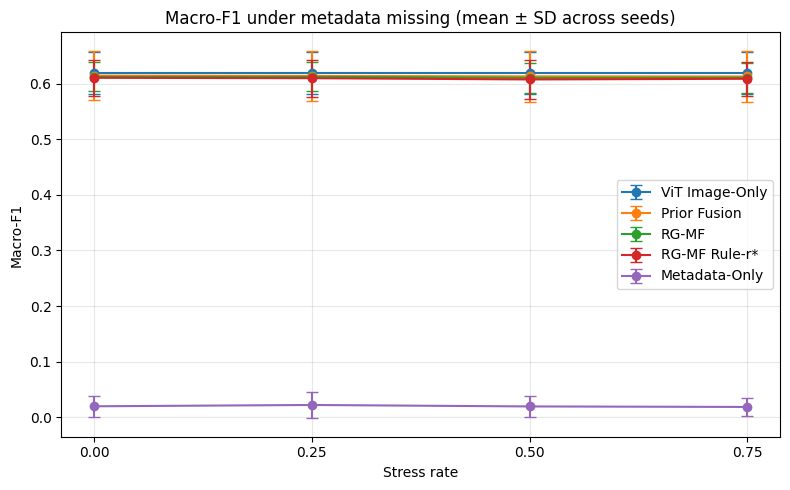

Saved: /content/ham10000_rg_mf_reviewer3_4_results/fig_macro_f1_missing_mean_sd.png


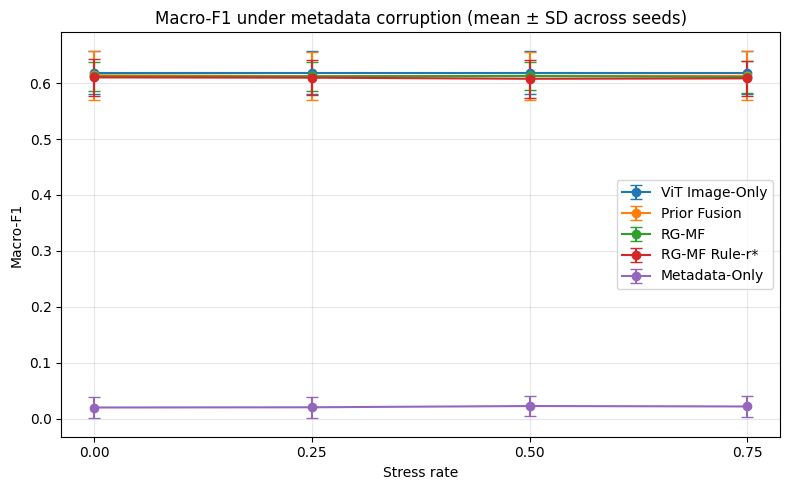

Saved: /content/ham10000_rg_mf_reviewer3_4_results/fig_macro_f1_corruption_mean_sd.png


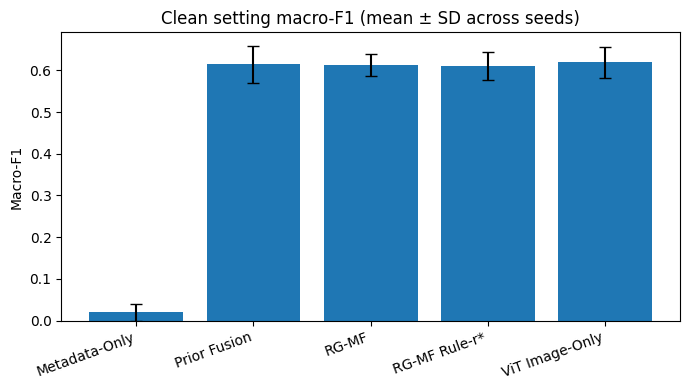

Saved: /content/ham10000_rg_mf_reviewer3_4_results/fig_clean_macro_f1_mean_sd.png
Saved report: /content/ham10000_rg_mf_reviewer3_4_results/README_reviewer2_experiment_outputs.txt


In [25]:
# ============================================================
# 16. MANUSCRIPT-READY FIGURES
# ============================================================
summary_df = pd.read_csv(SAVE_DIR / "table_repeated_seed_mean_std_ci.csv")

# Robustness curves: mean macro-F1 with error bars.
for stress_type in STRESS_TYPES:
    plt.figure(figsize=(8, 5))
    temp = summary_df[summary_df["stress_type"] == stress_type].copy()

    for model_name in MODELS_TO_RUN:
        m = temp[temp["model"] == model_name].sort_values("stress_rate")
        if m.empty:
            continue
        plt.errorbar(
            m["stress_rate"],
            m["f1_macro_mean"],
            yerr=m["f1_macro_std"],
            marker="o",
            capsize=4,
            label=model_name,
        )

    plt.title(f"Macro-F1 under metadata {stress_type} (mean ± SD across seeds)")
    plt.xlabel("Stress rate")
    plt.ylabel("Macro-F1")
    plt.xticks(STRESS_RATES)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig_path = SAVE_DIR / f"fig_macro_f1_{stress_type}_mean_sd.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print("Saved:", fig_path)

# Clean setting bar chart.
clean_df = summary_df[(summary_df["stress_type"] == "missing") & (summary_df["stress_rate"] == 0.0)].copy()
clean_df = clean_df.sort_values("model")

plt.figure(figsize=(7, 4))
x = np.arange(len(clean_df))
plt.bar(x, clean_df["f1_macro_mean"], yerr=clean_df["f1_macro_std"], capsize=4)
plt.xticks(x, clean_df["model"], rotation=20, ha="right")
plt.ylabel("Macro-F1")
plt.title("Clean setting macro-F1 (mean ± SD across seeds)")
plt.tight_layout()
fig_path = SAVE_DIR / "fig_clean_macro_f1_mean_sd.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print("Saved:", fig_path)

# Text report.
report_path = SAVE_DIR / "README_reviewer2_experiment_outputs.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("HAM10000 RG-MF Reviewer-2 Rebuttal Experiment Outputs\n")
    f.write("=" * 70 + "\n\n")
    f.write("Main files:\n")
    f.write("1. all_results_repeated_seed.csv\n")
    f.write("2. table_repeated_seed_mean_std_ci.csv\n")
    f.write("3. table_degradation_summary.csv\n")
    f.write("4. table_paired_bootstrap_significance.csv\n")
    f.write("5. table_reliability_verification_summary.csv\n")
    f.write("6. table_rg_mf_inference_cue_ablation_summary.csv\n")
    f.write("7. table_cost_indicator_summary.csv\n\n")
    f.write("Reviewer 2 mapping:\n")
    f.write("- Single split/single run: answered by repeated SEEDS and grouped splits.\n")
    f.write("- No CI/significance: answered by bootstrap CI and paired bootstrap test.\n")
    f.write("- Non-monotonic stress: answered by deterministic nested stress masks and mean±SD across seeds.\n")
    f.write("- Reliability head collapse: answered by r_target anchoring and reliability correlation analysis.\n")
    f.write("- No availability/plausibility ablation: answered by inference cue ablation.\n")
    f.write("- No cost indicator: answered by parameter and latency table.\n")
    f.write("- MAE/RMSE: removed from all main metrics.\n")

print("Saved report:", report_path)

## 19. Reviewer 3/4 output map

Cell ini membuat file ringkasan yang memetakan output CSV/PNG ke komentar reviewer terbaru.


In [26]:
# ============================================================
# 19. REVIEWER 3/4 OUTPUT MAP
# ============================================================
reviewer34_map = [
    ["Rule-based r* gate baseline", "table_repeated_seed_mean_std_ci.csv; table_reviewer34_gate_probe_summary.csv", "Reviewer 3 and 4 request direct rule-based r* gate comparison."],
    ["Metadata contribution / image-dominated analysis", "table_metadata_contribution_clean_to_zero_summary.csv; table_modality_norm_probe_summary.csv", "Quantifies whether metadata contributes materially or the classifier is image-dominated."],
    ["Non-MCAR targeted stress", "table_non_mcar_targeted_stress_summary.csv", "Adds conditional metadata degradation beyond MCAR-style nested masks."],
    ["Exact corruption and plausibility rules", "table_corruption_plausibility_rules.csv", "Specifies age, sex, and site corruption and plausibility procedures."],
    ["Source-code reproducibility package", "Notebook + exported CSV/PNG/ZIP", "Files are ready to be uploaded to GitHub/Zenodo/Code Ocean."],
]
reviewer34_map_df = pd.DataFrame(reviewer34_map, columns=["reviewer_issue", "output_files", "use_in_manuscript_or_response"])
reviewer34_map_df.to_csv(SAVE_DIR / "README_reviewer3_4_output_map.csv", index=False)
display(reviewer34_map_df)
print("Saved:", SAVE_DIR / "README_reviewer3_4_output_map.csv")


,reviewer_issue,output_files,use_in_manuscript_or_response
0,Rule-based r* gate baseline,table_repeated_seed_mean_std_ci.csv; table_rev...,Reviewer 3 and 4 request direct rule-based r* ...
1,Metadata contribution / image-dominated analysis,table_metadata_contribution_clean_to_zero_summ...,Quantifies whether metadata contributes materi...
2,Non-MCAR targeted stress,table_non_mcar_targeted_stress_summary.csv,Adds conditional metadata degradation beyond M...
3,Exact corruption and plausibility rules,table_corruption_plausibility_rules.csv,"Specifies age, sex, and site corruption and pl..."
4,Source-code reproducibility package,Notebook + exported CSV/PNG/ZIP,Files are ready to be uploaded to GitHub/Zenod...


Saved: /content/ham10000_rg_mf_reviewer3_4_results/README_reviewer3_4_output_map.csv


In [27]:
# ============================================================
# 22. EXPORT AND SYNC RESULTS TO GOOGLE DRIVE
# ============================================================
# Setelah eksperimen selesai, cell ini mengarsipkan seluruh output lokal ke ZIP
# dan menyalinnya ke Google Drive agar tidak hilang saat runtime Colab berhenti.

if SAVE_DIR.exists():
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    zip_base = Path("/content/ham10000_rg_mf_reviewer3_4_results")
    zip_path = Path(str(zip_base) + ".zip")
    if zip_path.exists():
        zip_path.unlink()
    shutil.make_archive(str(zip_base), "zip", root_dir=SAVE_DIR)
    drive_zip_path = DRIVE_RESULTS_DIR / zip_path.name
    shutil.copy2(zip_path, drive_zip_path)
    print("[OK] ZIP hasil eksperimen disimpan ke:", zip_path)
    print("[OK] ZIP hasil eksperimen disalin ke Google Drive:", drive_zip_path)

    # Copy main CSV/PNG files for quick access.
    for p in SAVE_DIR.glob("*"):
        if p.is_file() and p.suffix.lower() in {".csv", ".png", ".txt"}:
            shutil.copy2(p, DRIVE_RESULTS_DIR / p.name)
    print("[OK] File CSV/PNG/TXT utama juga disalin ke:", DRIVE_RESULTS_DIR)
else:
    print("SAVE_DIR belum ada. Jalankan eksperimen terlebih dahulu.")


[OK] ZIP hasil eksperimen disimpan ke: /content/ham10000_rg_mf_reviewer3_4_results.zip
[OK] ZIP hasil eksperimen disalin ke Google Drive: /content/drive/MyDrive/ham10000_rg_mf_reviewer3_4_results/ham10000_rg_mf_reviewer3_4_results.zip
[OK] File CSV/PNG/TXT utama juga disalin ke: /content/drive/MyDrive/ham10000_rg_mf_reviewer3_4_results


## 23. Final sanity checklist sebelum update paper

Gunakan hasil dari folder `SAVE_DIR` untuk memperbarui paper dan response to reviewers.

Kriteria minimal agar aman untuk resubmission:
1. RG-MF harus tetap dilaporkan secara jujur bila ViT masih unggul pada clean setting.
2. Klaim utama cukup: **RG-MF improves robustness over Prior Fusion as metadata-aware fusion model**, bukan "mengalahkan ViT".
3. Masukkan mean ± SD/CI dari repeated seeds.
4. Masukkan paired bootstrap significance test RG-MF vs Prior Fusion.
5. Masukkan reliability verification: `r` turun ketika metadata quality turun dan berkorelasi positif dengan `r_target`.
6. Masukkan ablation cues.
7. Masukkan parameter count dan latency.
8. Jangan masukkan MAE/RMSE untuk klasifikasi tujuh kelas.